# mtDSB x Age DE analysis (pydeseq2, LRT-free)

In [305]:
import scanpy as sc
import decoupler as dc
import pertpy as pt
sc.set_figure_params(figsize=(3, 3), frameon=False)
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
import warnings
warnings.filterwarnings("ignore")

def make_pseudobulk(adata, celltype, ct_col="celltype_merged",
                    sample_cols=("mouse_id","genotype","age"),
                    layer="counts"):
    ad = adata[adata.obs[ct_col] == celltype].copy()
    if layer in ad.layers:
        X = ad.layers[layer]
    else:
        X = ad.X
    if sparse.issparse(X):
        X = X.tocsr()

    # define samples as unique combinations of sample_cols
    meta = ad.obs.loc[:, sample_cols].astype(str)
    meta["sample_id"] = meta.apply(lambda r: "_".join(r.values), axis=1)

    # aggregate counts by sample_id
    sample_ids = meta["sample_id"].values
    uniq = pd.Index(np.unique(sample_ids), name="sample_id")
    # map each cell to column index
    col_index = pd.Series(pd.Categorical(sample_ids, categories=uniq)).cat.codes.values

    # build counts: genes x samples
    n_genes = ad.n_vars
    n_samp  = len(uniq)
    M = np.zeros((n_genes, n_samp), dtype=np.int64)
    # fast aggregate with group-by via numpy
    for s in range(n_samp):
        idx = np.where(col_index == s)[0]
        if len(idx)==0: 
            continue
        Xi = X[idx]
        M[:, s] = Xi.sum(axis=0).A.ravel() if sparse.issparse(Xi) else Xi.sum(axis=0)

    # sample metadata frame
    smd = uniq.to_frame(index=False)
    # split back columns
    parts = smd["sample_id"].str.split("_", expand=True)
    for i, c in enumerate(sample_cols):
        smd[c] = parts[i].values
    smd["condition"] = smd["condition"].astype("category")
    # age: keep both categorical and numeric versions handy
    smd["age"] = smd["age"].astype(str)
    smd["age_num"] = pd.to_numeric(smd["age"], errors="coerce")

    # gene names
    genes = ad.var_names.to_list()

    return pd.DataFrame(M, index=genes, columns=smd["sample_id"]), smd.set_index("sample_id")

# =======================
# mtDSB x Age DE analysis (pydeseq2, LRT-free)
# - Per-age simple effects: model vs control
# - Interaction proxy: delta-LFC between ages with z-test
# Requirements: pydeseq2, anndata, numpy, pandas
# Assumes: pb[ct] = (counts_df [genes x samples], meta_df indexed by sample_id with columns "condition","age")
# =======================

import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
from anndata import AnnData
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# ---------- helpers ----------
def _align(counts_df, meta_df):
    if not counts_df.columns.equals(meta_df.index):
        common = counts_df.columns.intersection(meta_df.index)
        if len(common) == 0:
            raise ValueError("No overlapping sample IDs between counts_df.columns and meta_df.index")
        counts_df = counts_df.loc[:, common]
        meta_df   = meta_df.loc[common]
    return counts_df, meta_df

def _to_anndata(counts_df, meta_df):
    X = counts_df.T.astype(np.int64)  # samples x genes
    ad = AnnData(X=X.values)
    ad.obs_names = X.index.astype(str)
    ad.var_names = counts_df.index.astype(str)
    ad.obs = meta_df.copy()
    return ad

def _prep_condition(mdf, condition_col="condition", ref_condition="control"):
    mdf = mdf.copy()
    mdf[condition_col] = mdf[condition_col].astype(str).str.strip()
    uniq = list(pd.unique(mdf[condition_col]))
    if ref_condition not in uniq:
        m = [u for u in uniq if u.lower() == ref_condition.lower()]
        if not m:
            raise ValueError(f"Reference '{ref_condition}' not present. Found: {uniq}")
        ref_condition = m[0]
    mdf[condition_col] = pd.Categorical(
        mdf[condition_col],
        categories=[ref_condition] + [u for u in uniq if u != ref_condition],
        ordered=True
    )
    return mdf, ref_condition

def _detect_case(mdf, condition_col="condition", ref_condition="control"):
    cats = list(mdf[condition_col].cat.categories)
    case_levels = [c for c in cats if c != ref_condition]
    if len(case_levels) == 0:
        raise ValueError("No case level found (only control present).")
    return case_levels[0]

def _compute_gene_stats(counts_df, meta_df):
    """
    Compute gene-level stats to judge expression 'meaningfulness'.
    Returns DataFrame indexed by gene with:
      - mean_cpm_all, detect_rate_all
      - mean_cpm_cond_<cond> (per-condition)
      - mean_cpm_age_<age>   (per-age)
    """
    # CPM
    lib = counts_df.sum(axis=0).replace(0, np.nan)
    cpm = counts_df.divide(lib, axis=1) * 1e6

    gs = pd.DataFrame(index=counts_df.index)
    gs["mean_cpm_all"] = cpm.mean(axis=1)
    gs["detect_rate_all"] = (cpm > 0).mean(axis=1)

    if "condition" in meta_df.columns:
        for cond, cols in meta_df.groupby("condition").groups.items():
            cols = list(cols)
            if cols:
                gs[f"mean_cpm_cond_{cond}"] = cpm[cols].mean(axis=1)

    if "age" in meta_df.columns:
        for age, cols in meta_df.groupby("age").groups.items():
            cols = list(cols)
            if cols:
                gs[f"mean_cpm_age_{age}"] = cpm[cols].mean(axis=1)

    return gs

# ---------- DE pieces ----------
def simple_effect_at_age(counts_df, meta_df, age_value,
                         condition_col="condition", ref_condition="control",
                         n_cpus=8):
    counts_df, meta_df = _align(counts_df, meta_df)
    mask = meta_df["age"].astype(str).str.strip() == str(age_value)
    if mask.sum() < 2:
        raise ValueError(f"Not enough samples at age={age_value}")
    cdf = counts_df.loc[:, mask]
    mdf = meta_df.loc[mask].copy()

    mdf, ref_condition = _prep_condition(mdf, condition_col=condition_col, ref_condition=ref_condition)
    case_label = _detect_case(mdf, condition_col=condition_col, ref_condition=ref_condition)

    ad = _to_anndata(cdf, mdf)
    dds = DeseqDataSet(
        adata=ad,
        design_factors=[condition_col],
        refit_cooks=True,
        inference=DefaultInference(n_cpus=n_cpus),
    )
    dds.deseq2()

    st = DeseqStats(dds, contrast=[condition_col, case_label, ref_condition], inference=DefaultInference(n_cpus=n_cpus))
    st.summary()
    res = st.results_df.copy()
    res = res.rename(columns={
        "log2FoldChange": f"log2FC_{case_label}_vs_{ref_condition}",
        "lfcSE":          f"lfcSE_{case_label}_vs_{ref_condition}",
        "pvalue":         f"pvalue_{case_label}_vs_{ref_condition}",
        "padj":           f"padj_{case_label}_vs_{ref_condition}",
    })
    res.attrs = {"contrast": f"{case_label} vs {ref_condition} @ age {age_value}",
                 "age": str(age_value),
                 "case": case_label,
                 "ref": ref_condition}
    return res

def combine_delta_lfc(res_a, res_b):
    lfc_col_a = [c for c in res_a.columns if c.startswith("log2FC_")][0]
    se_col_a  = [c for c in res_a.columns if c.startswith("lfcSE_")][0]
    lfc_col_b = [c for c in res_b.columns if c.startswith("log2FC_")][0]
    se_col_b  = [c for c in res_b.columns if c.startswith("lfcSE_")][0]

    df = pd.DataFrame(index=res_a.index.union(res_b.index))
    df[lfc_col_a] = res_a[lfc_col_a]
    df[se_col_a]  = res_a[se_col_a]
    df[lfc_col_b] = res_b[lfc_col_b]
    df[se_col_b]  = res_b[se_col_b]

    df = df.dropna(subset=[lfc_col_a, se_col_a, lfc_col_b, se_col_b]).copy()

    df["delta_log2FC"] = df[lfc_col_b] - df[lfc_col_a]
    df["se_delta"] = np.sqrt(np.square(df[se_col_a]) + np.square(df[se_col_b]))
    df["se_delta"] = df["se_delta"].replace(0, np.nan)
    df = df.dropna(subset=["se_delta"])
    from scipy.stats import norm
    df["z"] = df["delta_log2FC"] / df["se_delta"]
    df["p_delta"] = 2 * (1 - norm.cdf(np.abs(df["z"])))
    df["q_delta"] = multipletests(df["p_delta"], method="fdr_bh")[1]
    return df

# ---------- main runner with gene stats joined ----------
def run_all(pb, condition_col="condition", outdir=None, n_cpus=8, save_csv=False):
    """
    For each cell type:
      - per-age simple effects (model vs control)
      - pairwise delta-LFC interaction proxy
      - gene_stats computed once and JOINED onto every table
    """
    if save_csv and outdir:
        os.makedirs(outdir, exist_ok=True)

    results = {}
    for ct, (counts_df, meta_df) in pb.items():
        # ensure alignment & compute gene stats once
        counts_df, meta_df = _align(counts_df, meta_df)
        gene_stats = _compute_gene_stats(counts_df, meta_df)

        ages = list(pd.unique(meta_df["age"].astype(str).str.strip()))
        per_age = {}

        # simple effects (join stats)
        for a in ages:
            try:
                res = simple_effect_at_age(counts_df, meta_df, a,
                                           condition_col=condition_col,
                                           ref_condition="control",
                                           n_cpus=n_cpus)
                res = res.join(gene_stats, how="left")
                per_age[a] = res
                if save_csv and outdir:
                    res.to_csv(os.path.join(outdir, f"{ct.replace(' ','_')}_simple_effect_age_{a}.csv"))
            except Exception as e:
                per_age[a] = None
                print(f"[{ct}] simple-effect failed at age={a}: {e}")

        # deltas (join stats)
        deltas = {}
        age_pairs = []
        for i in range(len(ages)):
            for j in range(i+1, len(ages)):
                a, b = ages[i], ages[j]
                if per_age.get(a) is None or per_age.get(b) is None:
                    continue
                dtab = combine_delta_lfc(per_age[a], per_age[b])
                dtab = dtab.join(gene_stats, how="left")
                dtab.attrs = {"age_A": a, "age_B": b,
                              "note": "delta_log2FC = LFC(age_B) - LFC(age_A)"}
                deltas[(a,b)] = dtab
                age_pairs.append((a,b))
                if save_csv and outdir:
                    dtab.to_csv(os.path.join(outdir, f"{ct.replace(' ','_')}_deltaLFC_{a}_vs_{b}.csv"))

        results[ct] = {
            "simple_effects": per_age,
            "deltas": deltas,
            "ages": ages,
            "age_pairs": age_pairs,
            "gene_stats": gene_stats,     # <--- stored for convenience
        }

    return results



## Read data

In [298]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_with_raw.h5ad')

In [299]:
adata.X = adata.layers['counts']
adata.X = adata.X.astype(int)

In [300]:
glia_classes = [
    # --- Astrocytes ---
    "Telencephalon astrocytes",
    "Olfactory astrocytes",

    # --- Oligodendrocyte lineage ---
    "Mature oligodendrocytes",
    "Oligodendrocytes precursor cells",

    # --- Microglia ---
    "Microglia",
]

In [301]:
adata = adata[adata.obs.cell_class.isin(glia_classes)]

In [302]:
adata

View of AnnData object with n_obs × n_vars = 335167 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'cell_class_colors', 'cell_type_colors', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Perform pseudobulk

In [306]:
celltypes = adata.obs.cell_class.unique()
pb = {}   # dict: celltype -> (count_df, sample_metadata)
for ct in celltypes:
    pb[ct] = make_pseudobulk(adata, celltype=ct, ct_col = 'cell_class', sample_cols = ('sample_id', 'condition', 'age'))

## Perform DGE

In [307]:
results = run_all(pb, condition_col="condition", outdir=None, n_cpus=8, save_csv=False)

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.21 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.10 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: condition mtDSB vs control
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik  1182.305468        0.208897  0.145926  1.431532  0.152278   
9630013A20Rik  2105.138848        0.365869  0.269775  1.356202  0.175035   
A1cf              3.589109       -1.841412  1.147881 -1.604184  0.108673   
A2m             342.022173        1.038859  0.294281  3.530157  0.000415   
Aatf           1446.297850        0.127922  0.164387  0.778176  0.436465   
...                    ...             ...       ...       ...       ...   
Zswim9          235.080892       -0.150295  0.196322 -0.765556  0.443941   
Zup1            275.153589        0.054504  0.180005  0.302790  0.762050   
Zyx             691.700478        0.153414  0.237869  0.644950  0.518960   
Zzef1          1178.695495       -0.113610  0.130920 -0.867786  0.385511   
a                 2.834891       -1.652620  1.408721 -1.173135  0.240742   

                   pad

Fitting dispersions...
... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.11 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


...

... done in 0.18 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.12 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: condition mtDSB vs control
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik   411.503575       -0.133353  0.188954 -0.705743  0.480348   
9630013A20Rik    51.188247        0.416654  0.396306  1.051343  0.293101   
A1cf              0.079560        0.572618  4.450717  0.128657  0.897629   
A2m            1541.485582        1.322683  0.642878  2.057438  0.039644   
Aatf            300.349754        0.092888  0.166805  0.556867  0.577618   
...                    ...             ...       ...       ...       ...   
Zswim9           98.905086       -0.022812  0.232677 -0.098043  0.921898   
Zup1            148.917616        0.073714  0.265802  0.277327  0.781529   
Zyx             188.738718        0.163536  0.255826  0.639245  0.522664   
Zzef1           365.409002       -0.136122  0.150355 -0.905335  0.365288   
a                 0.860713       -1.001060  2.034822 -0.491964  0.622745   

                   pad

... done in 0.17 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...


Log2 fold change & Wald test p-value: condition mtDSB vs control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik  297.615705        0.146153  0.145171  1.006763  0.314049   
9630013A20Rik   24.582750        0.084309  0.429730  0.196190  0.844461   
A1cf             0.000000             NaN       NaN       NaN       NaN   
A2m            734.017821        0.678906  0.473108  1.434991  0.151290   
Aatf           269.309163        0.158944  0.167180  0.950736  0.341739   
...                   ...             ...       ...       ...       ...   
Zswim9          68.830959       -0.290135  0.241918 -1.199312  0.230407   
Zup1           109.258887        0.038648  0.218423  0.176942  0.859554   
Zyx            128.378709       -0.048261  0.212205 -0.227427  0.820092   
Zzef1          316.284782       -0.015262  0.180454 -0.084578  0.932597   
a                0.497704       -0.945239  2.866733 -0.329727  0.741606   

                   padj  
2610035D

... done in 0.23 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.11 seconds.



In [262]:
import numpy as np
import matplotlib.pyplot as plt

def plot_lfc_across_ages_grid(
    results,
    ct,
    genes,
    q=0.05,
    ncols=4,
    figsize=(16, 9),
    sharey=True,
    fontsize_base=13
):
    """
    Plot log2FC across ages for multiple genes in subplots for a given cell type.
    Red dots = padj < q, grey = non-significant.
    Shared y-axis and increased text sizes for clarity.
    """
    ages = results[ct]["ages"]
    try:
        ages = sorted(ages, key=lambda x: float(x))
    except Exception:
        ages = sorted(ages)

    n_genes = len(genes)
    nrows = int(np.ceil(n_genes / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        sharex=True,
        sharey=sharey,
        constrained_layout=True
    )
    axes = np.ravel(axes)

    for i, gene in enumerate(genes):
        ax = axes[i]
        lfc, padj = [], []

        for a in ages:
            res = results[ct]["simple_effects"].get(a)
            if res is not None and gene in res.index:
                lfc_col = next(c for c in res.columns if c.startswith("log2FC_"))
                padj_col = next(c for c in res.columns if c.startswith("padj_"))
                lfc.append(res.loc[gene, lfc_col])
                padj.append(res.loc[gene, padj_col])
            else:
                lfc.append(np.nan)
                padj.append(np.nan)

        sig_mask = np.array(padj) < q
        ax.plot(ages, lfc, lw=1.5, c="black", zorder=2)
        ax.scatter(
            ages, lfc,
            c=["red" if s else "grey" for s in sig_mask],
            s=60, zorder=3
        )
        ax.axhline(0, ls="--", c="0.4", lw=1.0, zorder=1)

        # larger fonts for readability
        ax.set_title(gene, fontsize=fontsize_base, pad=6)
        ax.tick_params(axis='x', labelrotation=45, labelsize=fontsize_base - 2)
        ax.tick_params(axis='y', labelsize=fontsize_base - 2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # global labels — offset + larger text
    fig.suptitle(f"{ct}: log₂FC (mtDSB vs control) across ages",
                 fontsize=fontsize_base + 3, y=1.05, fontweight="bold")
    fig.text(0.5, -0.03, "Age (weeks)", ha="center", fontsize=fontsize_base + 1)
    fig.text(-0.04, 0.5, "log₂FC", va="center", rotation="vertical", fontsize=fontsize_base + 1)

    plt.subplots_adjust(bottom=0.12, left=0.10, right=0.98, top=0.93, wspace=0.25, hspace=0.35)
    plt.show()

In [263]:
results.keys()

dict_keys(['Mature oligodendrocytes', 'Telencephalon astrocytes', 'Microglia', 'Oligodendrocytes precursor cells', 'Olfactory astrocytes'])

2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

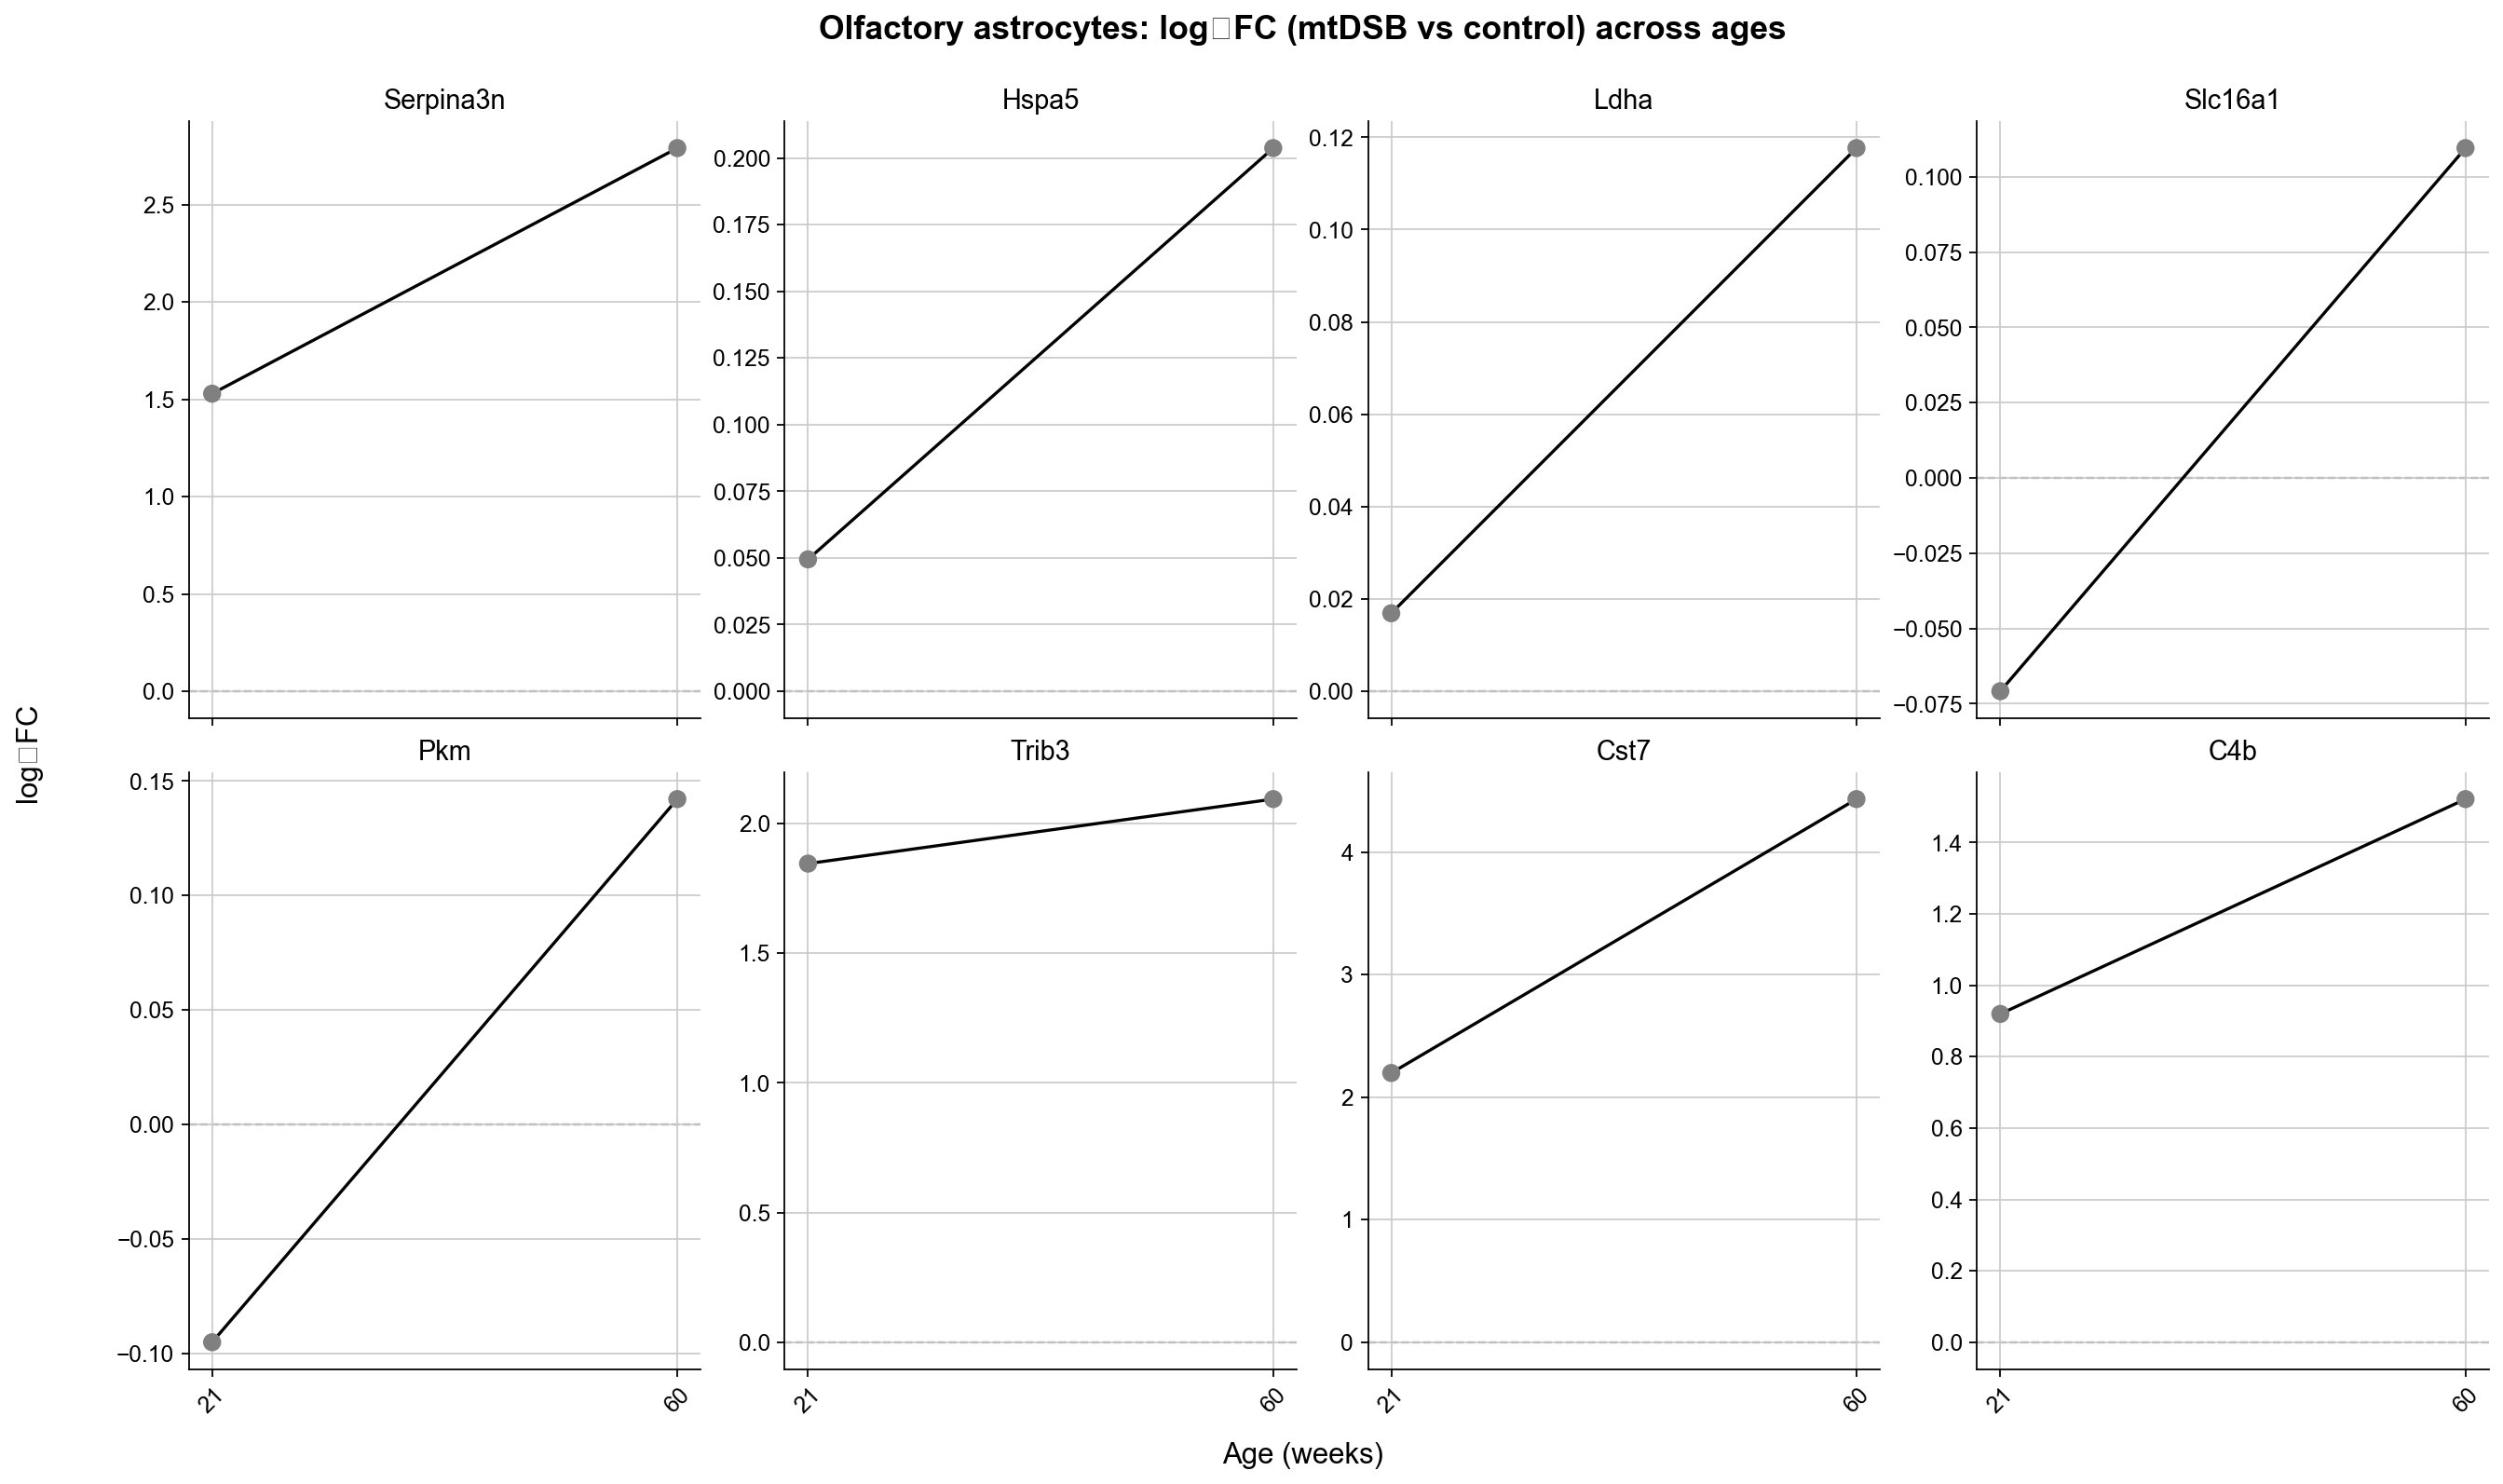

In [264]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_lfc_across_ages_grid(results, "Olfactory astrocytes", genes, sharey=False)

2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

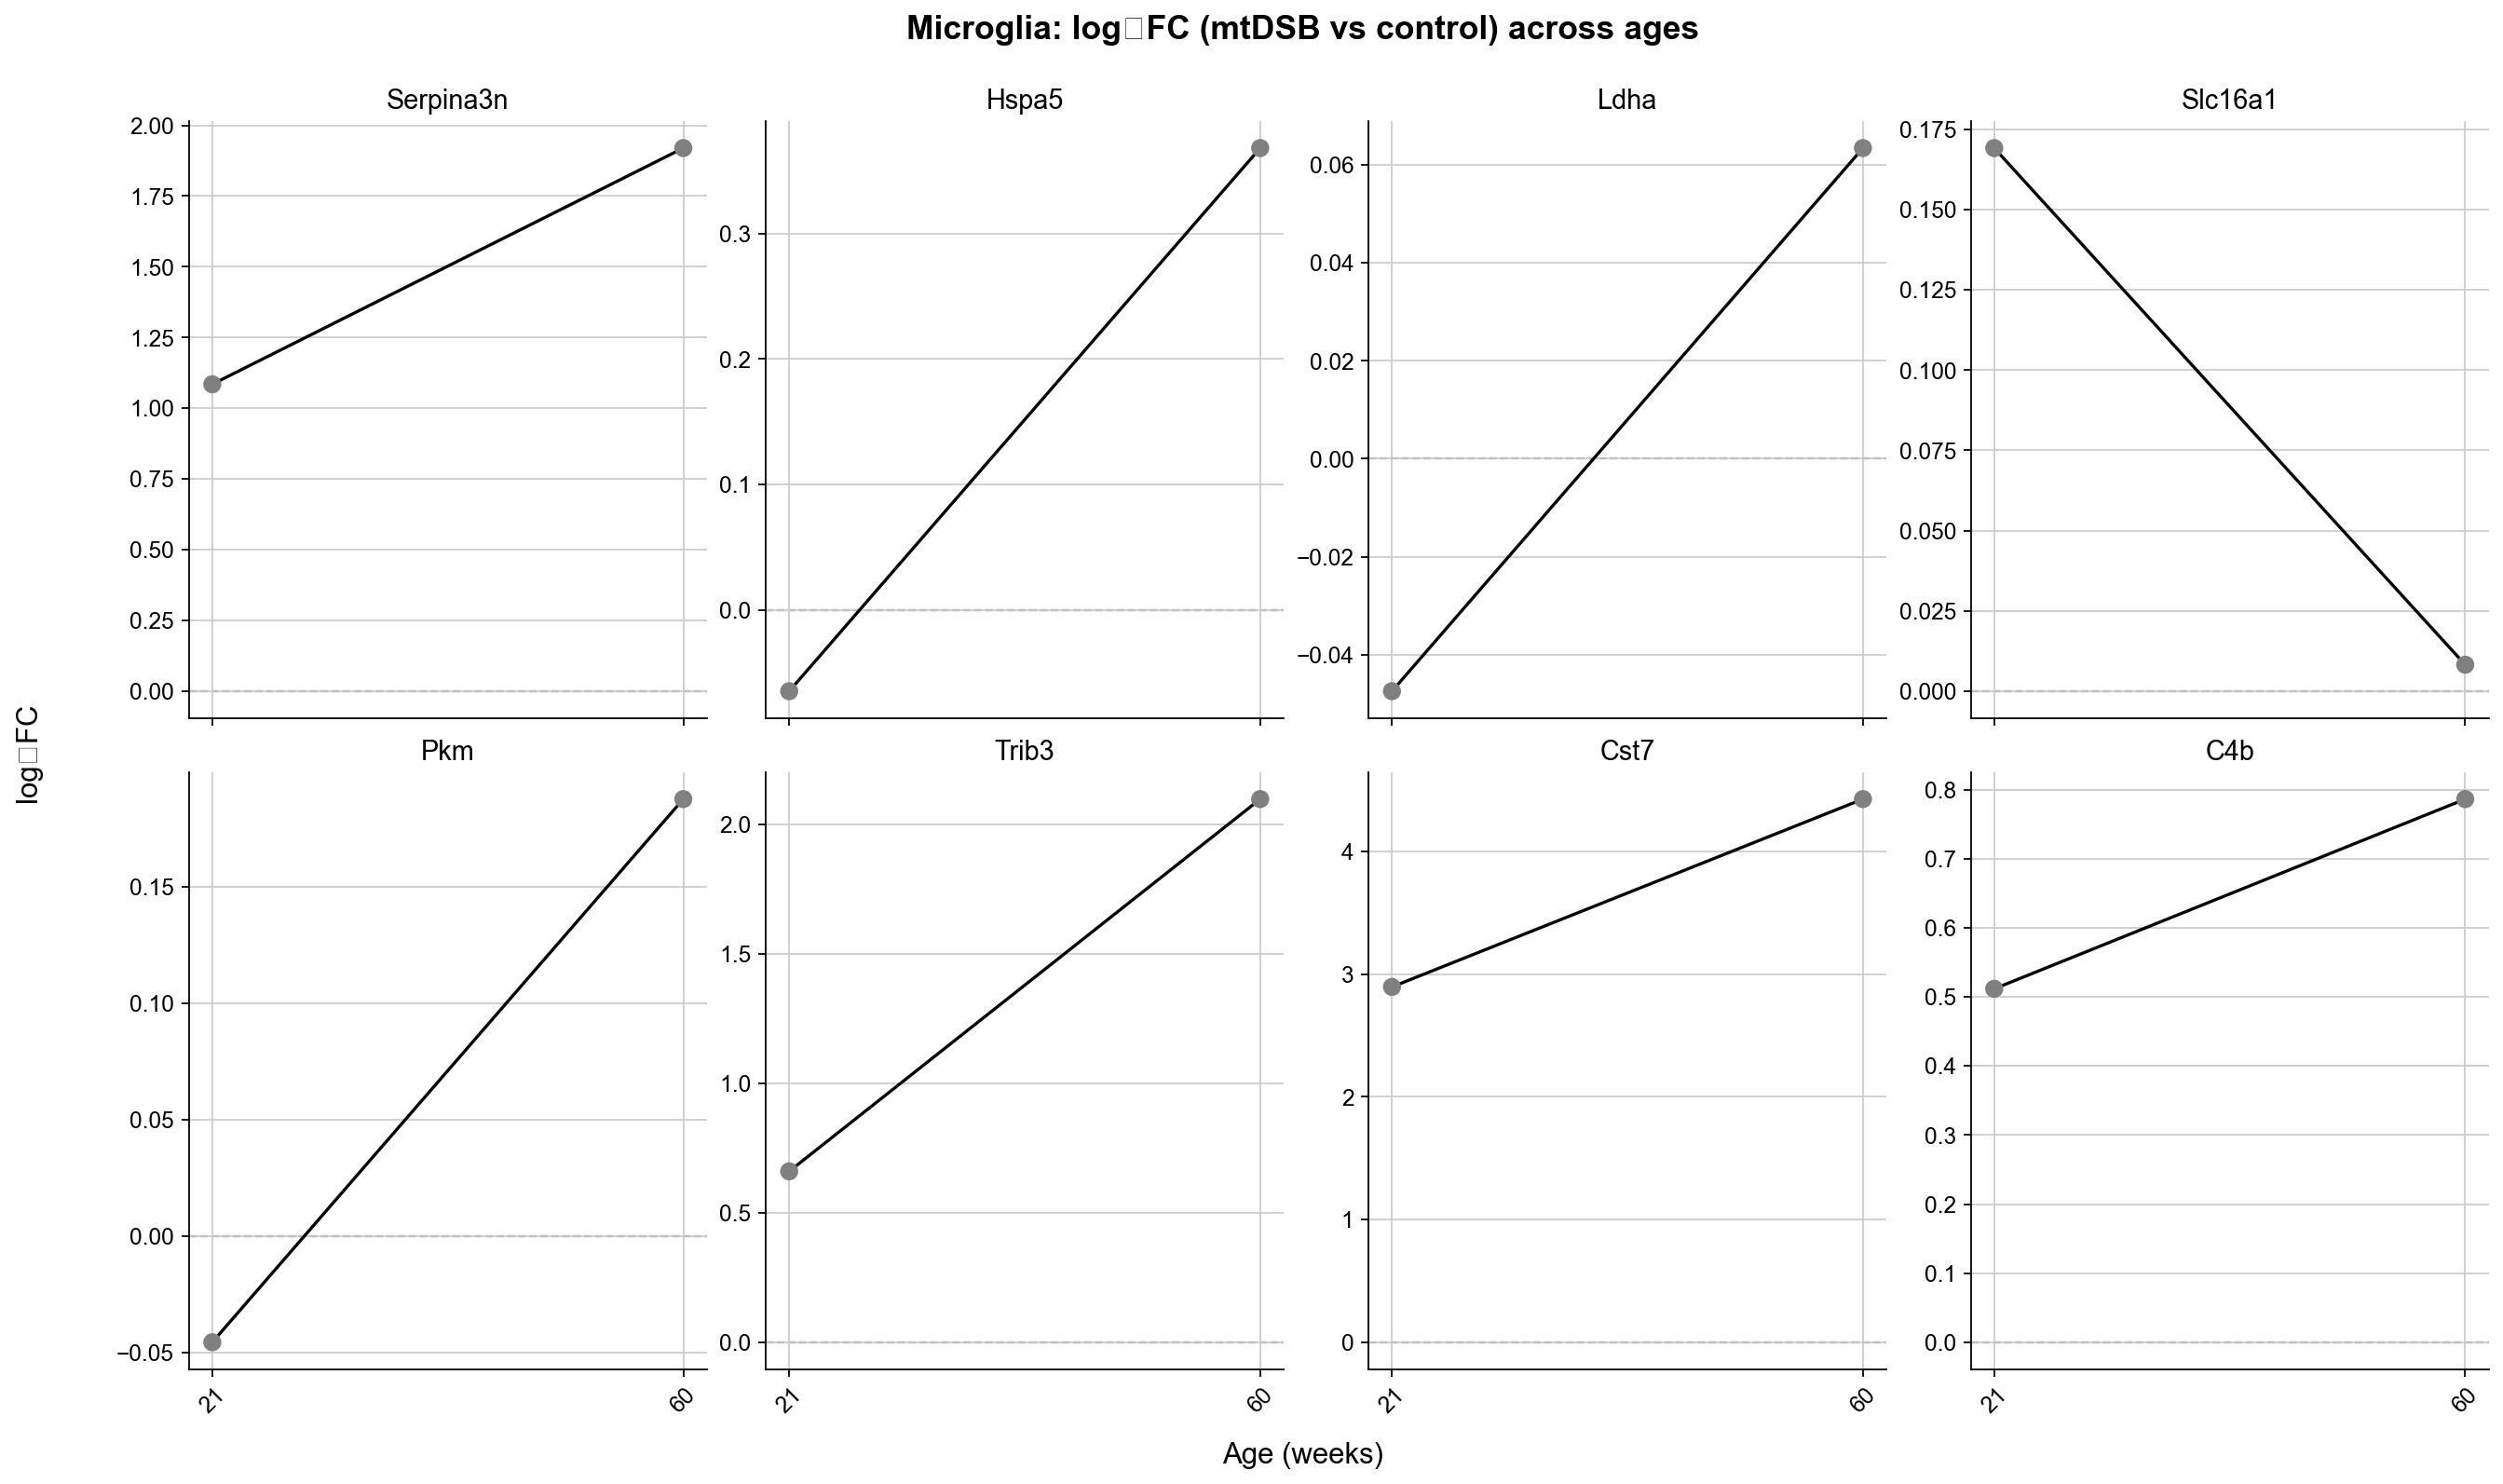

In [265]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_lfc_across_ages_grid(results, "Microglia", genes, sharey=False)

2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

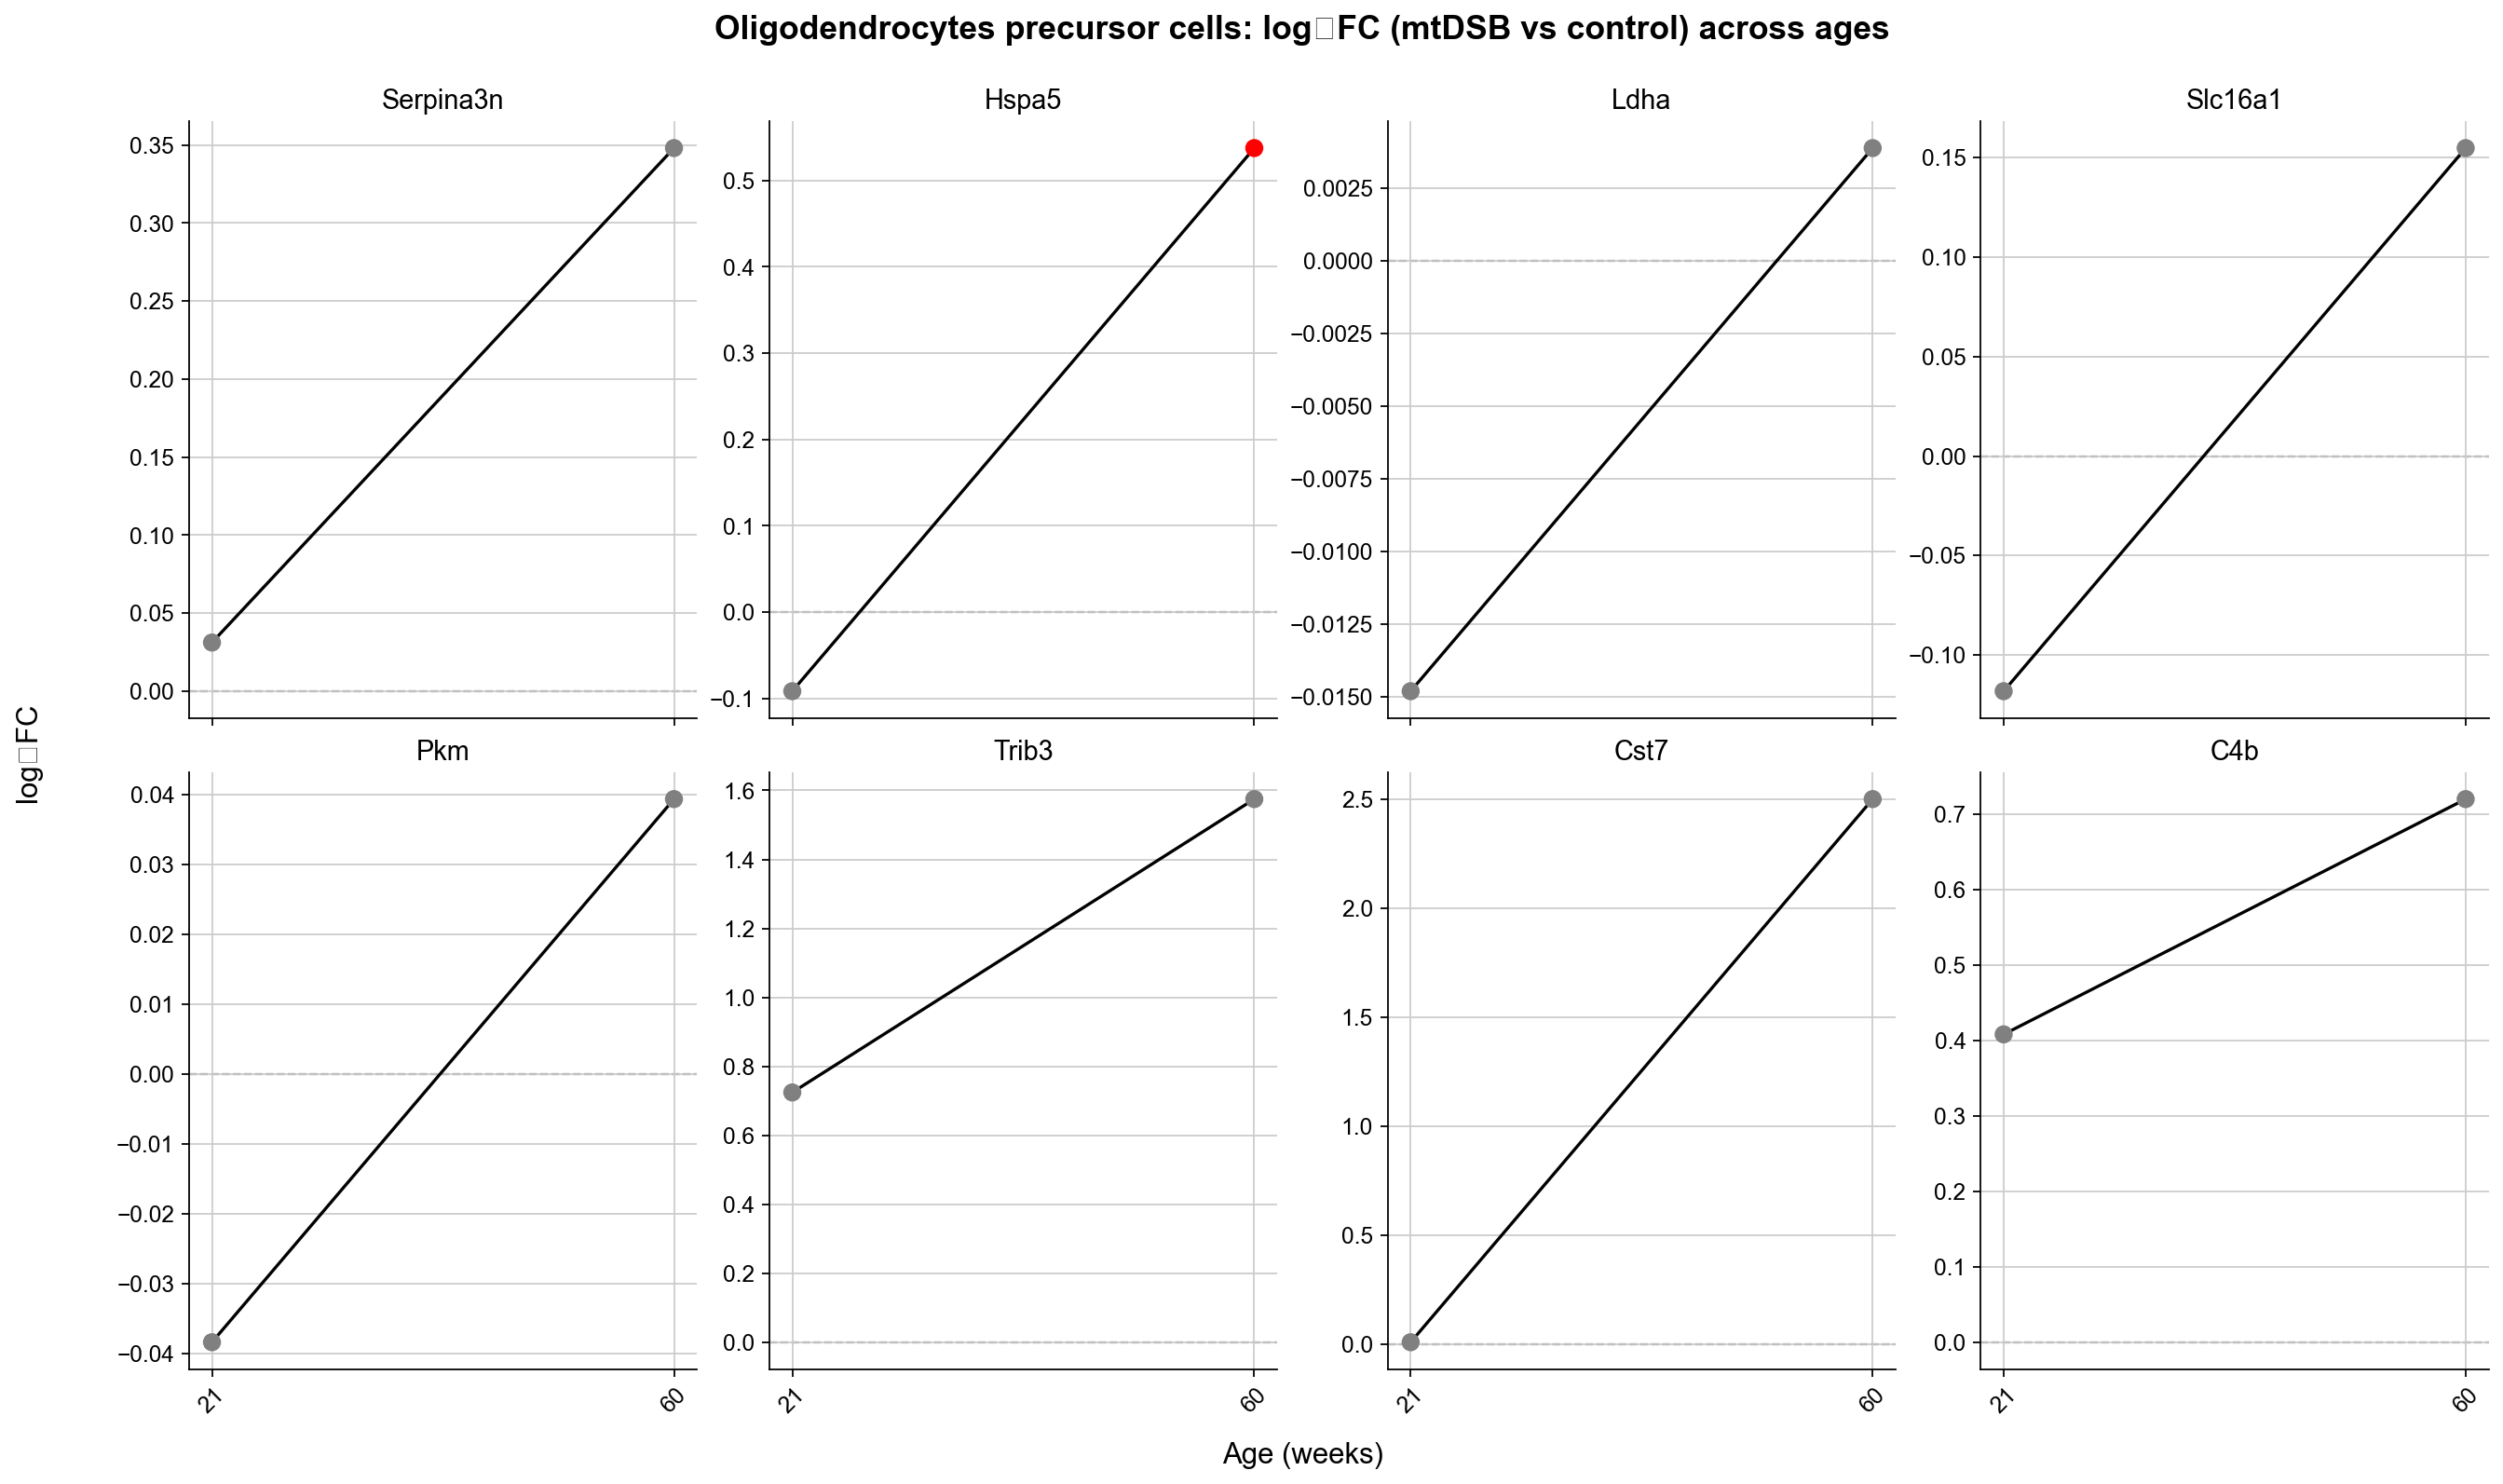

In [266]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_lfc_across_ages_grid(results, "", genes, sharey=False)

2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

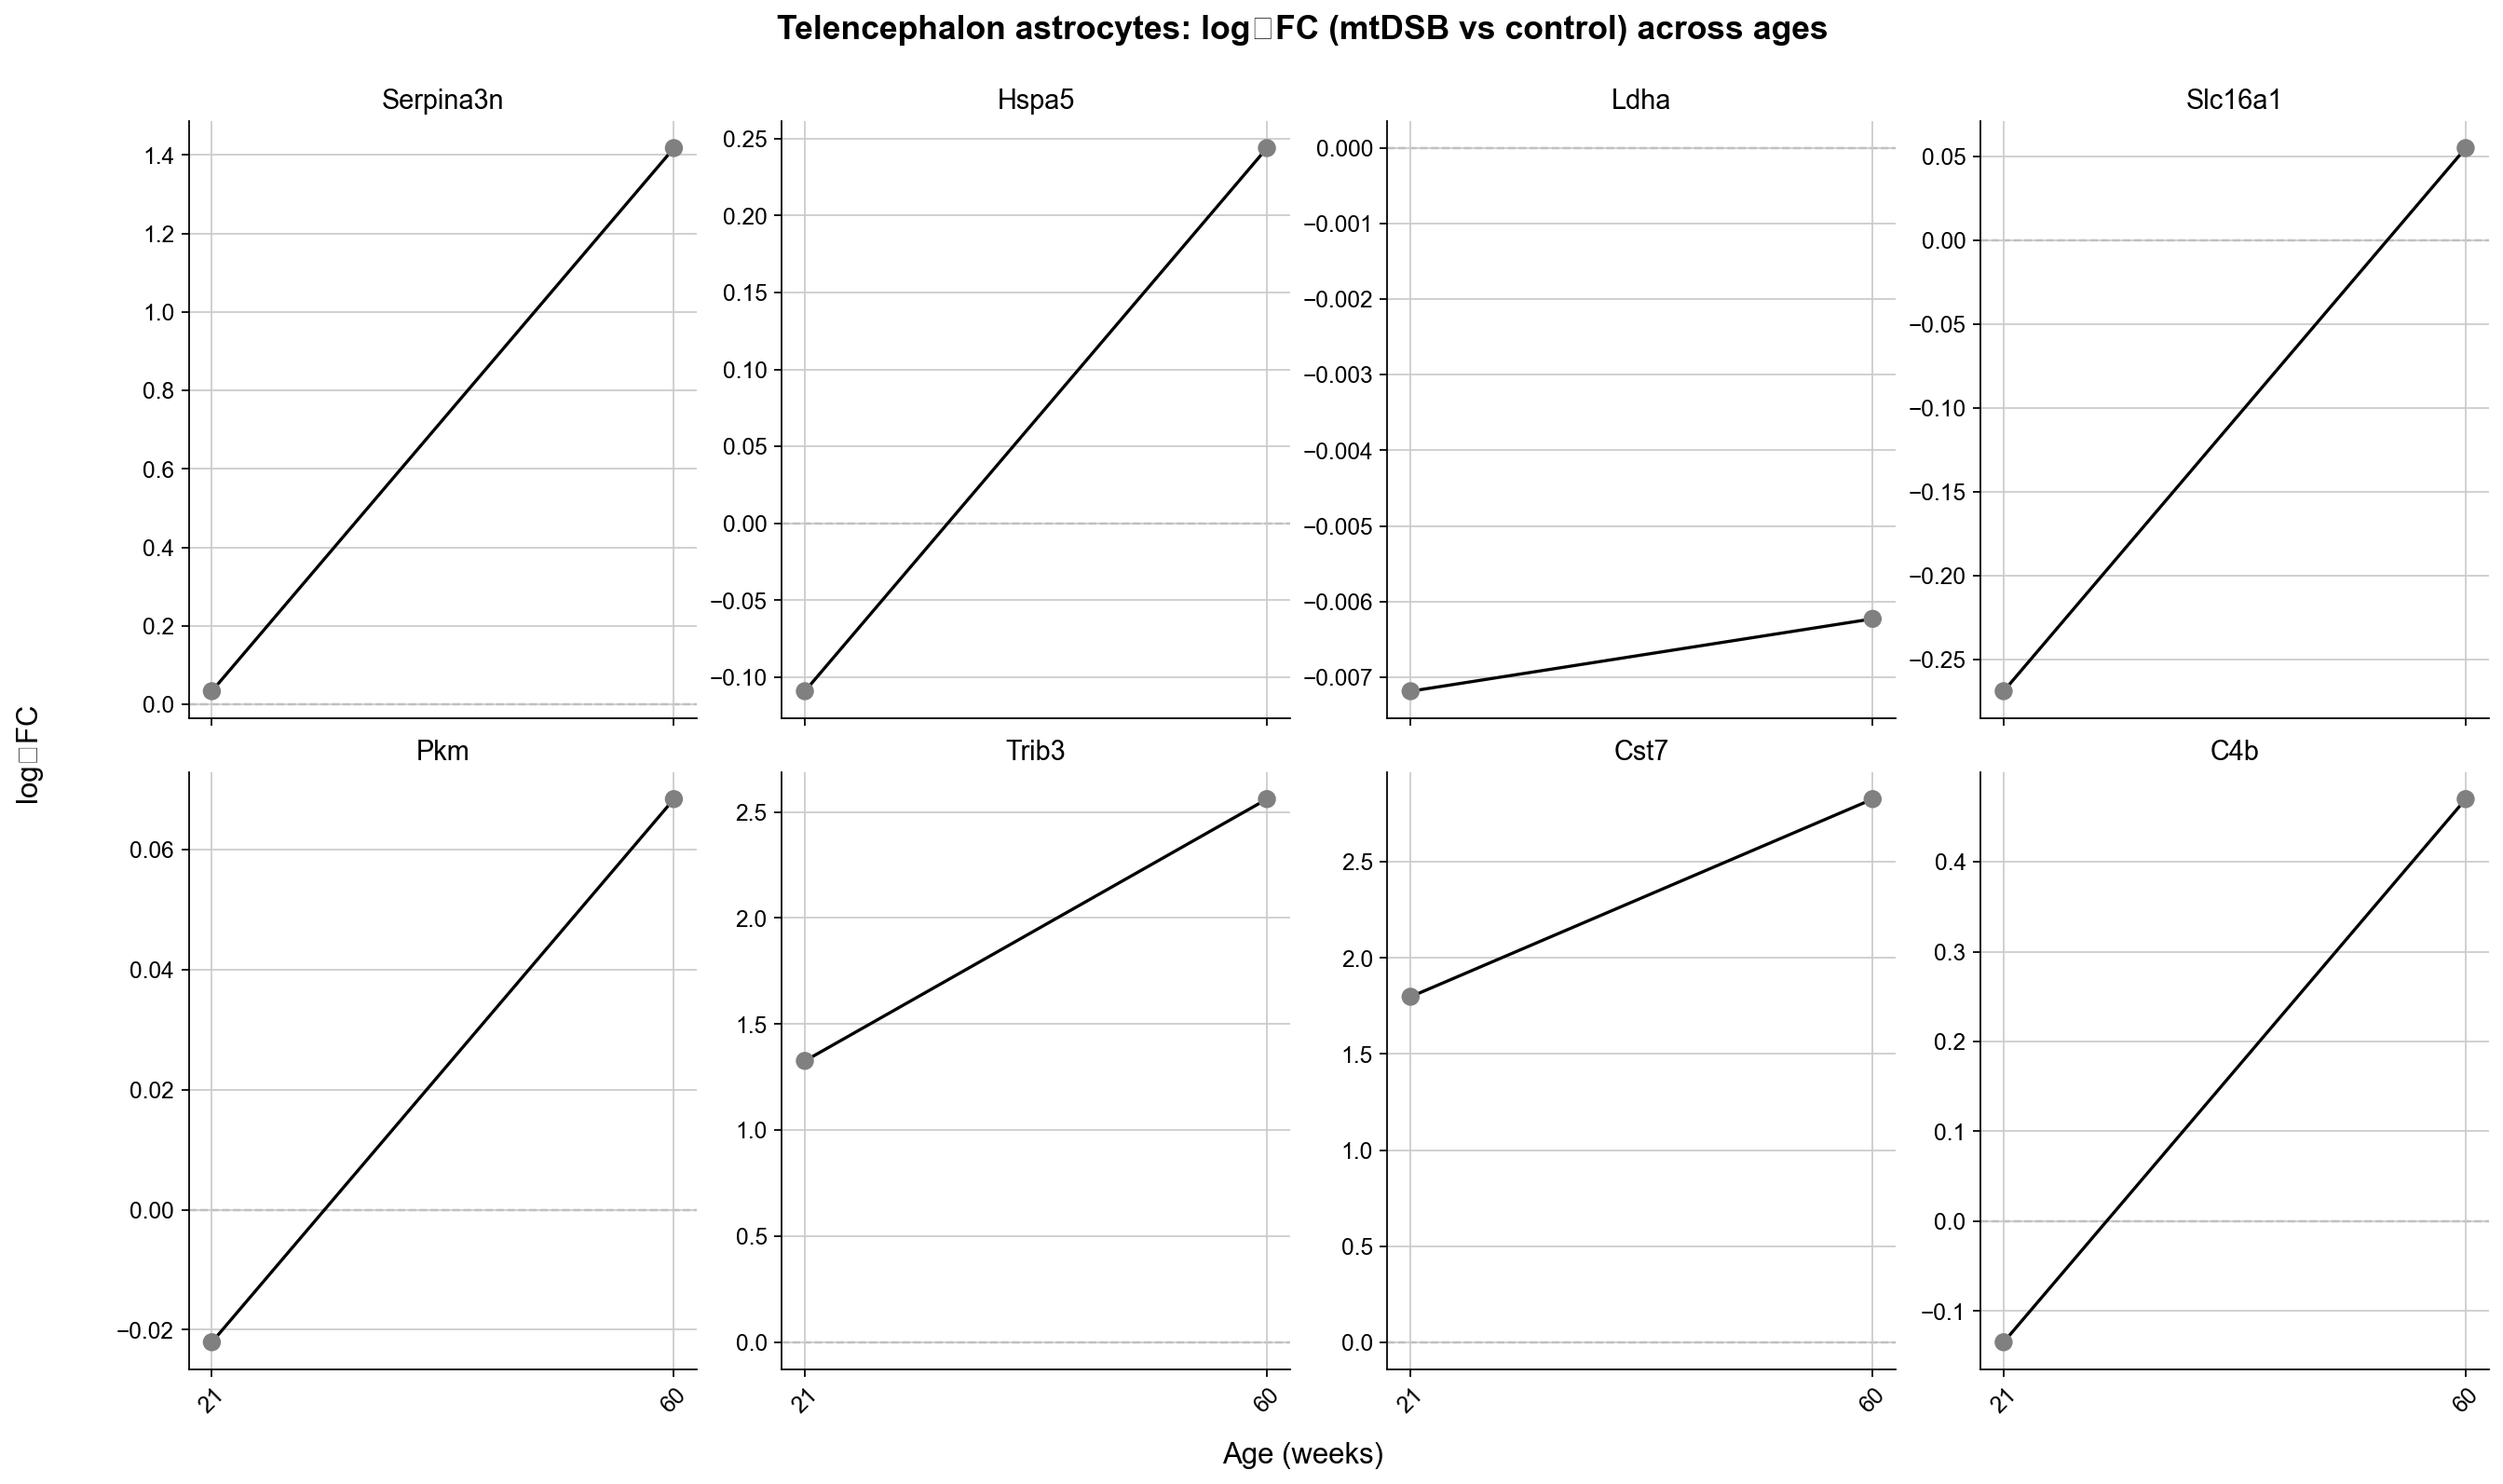

In [267]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_lfc_across_ages_grid(results, "Telencephalon astrocytes", genes, sharey=False)

In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import math

def plot_expression_by_condition_grid(
    pb,
    ct,
    genes,
    norm=True,                 # CPM-normalize per sample
    q=None,                    # optional: highlight sig ages (not used here; keep for parity)
    ncols=4,                   # number of subplot columns
    sharey=True,               # share y-axis across genes for magnitude comparison
    figsize_per_panel=(4.0, 3.2),
    fontsize_base=13,
    suppress_warnings=True
):
    """
    Multi-panel plot of mean expression (pseudobulk) across ages for each condition.

    pb: dict-like, pb[ct] = (counts_df [genes x samples], meta_df [samples x meta])
    ct: cell class key present in pb
    genes: list of gene symbols to plot
    norm: if True, CPM-normalize per-sample library size before group averaging
    sharey: if True, use shared y-axis across all gene subplots
    """

    if suppress_warnings:
        warnings.filterwarnings("ignore")

    counts_df, meta_df = pb[ct]
    # keep only genes that exist
    genes_present = [g for g in genes if g in counts_df.index]
    missing = sorted(set(genes) - set(genes_present))
    if missing:
        print(f"Skipping missing genes ({len(missing)}): {', '.join(missing[:8])}" + ("..." if len(missing)>8 else ""))

    if len(genes_present) == 0:
        print("No requested genes found in counts_df.")
        return

    # Build long table for requested genes
    # sample-wise counts and metadata
    dat = counts_df.loc[genes_present].T  # samples x genes
    df = dat.stack().reset_index()
    df.columns = ["sample", "gene", "counts"]

    # attach meta
    meta = meta_df.copy()
    meta = meta.loc[df["sample"].unique()]  # ensure order/coverage
    # basic hygiene
    meta = meta.assign(
        age=meta["age"].astype(str).str.strip(),
        condition=meta["condition"].astype(str).str.strip()
    )
    df = df.merge(meta[["age", "condition"]], left_on="sample", right_index=True, how="left")

    # CPM normalize if requested
    if norm:
        lib_sizes = counts_df.sum(axis=0)  # per-sample library size
        df["cpm"] = df.apply(lambda r: (r["counts"] / lib_sizes.loc[r["sample"]]) * 1e6, axis=1)
        val_col = "cpm"
    else:
        val_col = "counts"

    # aggregate mean ± sem per condition × age × gene
    agg = (
        df.groupby(["gene", "condition", "age"], observed=True)[val_col]
          .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)) if len(x)>1 else 0.0)
          .reset_index()
    )

    # sort ages numerically if possible
    try:
        age_order = sorted(agg["age"].unique(), key=lambda x: float(x))
    except Exception:
        age_order = sorted(agg["age"].unique())

    # figure layout
    n = len(genes_present)
    nrows = math.ceil(n / ncols)
    fig_w = max(ncols * figsize_per_panel[0], 6.0)
    fig_h = max(nrows * figsize_per_panel[1], 3.5)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        sharex=True,
        sharey=sharey,
        constrained_layout=True
    )
    axes = np.ravel(axes)

    # If sharey=True, compute global y-limits from all panels for consistency
    ymins, ymaxs = [], []
    if sharey:
        for g in genes_present:
            sub = agg[agg["gene"] == g]
            if sub.empty:
                continue
            ymins.append((sub["mean"] - sub["sem"]).min())
            ymaxs.append((sub["mean"] + sub["sem"]).max())
        if ymins and ymaxs:
            y_min = 0 if norm else min(0, np.nanmin(ymins))
            y_max = np.nanmax(ymaxs) * 1.08
        else:
            y_min, y_max = None, None

    # per-plot drawing
    for i, g in enumerate(genes_present):
        ax = axes[i]
        sub = agg[agg["gene"] == g].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        # draw each condition line with error bars
        for cond, grp in sub.groupby("condition", observed=True):
            grp = grp.set_index("age").reindex(age_order).reset_index()
            ax.errorbar(
                grp["age"], grp["mean"], yerr=grp["sem"],
                marker="o", capsize=4, lw=2.0, markersize=6, label=str(cond)
            )

        ax.axhline(0, ls="--", color="0.7", lw=1)  # helpful baseline (works for CPM too)
        ax.set_title(g, fontsize=fontsize_base, pad=6)
        ax.tick_params(axis="x", labelrotation=45, labelsize=fontsize_base-2)
        ax.tick_params(axis="y", labelsize=fontsize_base-2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # set shared y limits if requested
        if sharey and (y_min is not None) and (y_max is not None):
            ax.set_ylim(y_min, y_max)

        # lightweight legend per first subplot only
        if i == 0:
            ax.legend(frameon=False, fontsize=fontsize_base-2, title="Condition", title_fontsize=fontsize_base-2)
        else:
            ax.legend().remove()

    # hide unused panels
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    # global labels offset away from plots
    units = "CPM" if norm else "counts"
    fig.suptitle(f"{ct}: mean {units} across ages by condition",
                 fontsize=fontsize_base+3, y=1.04, fontweight="bold")
    fig.text(0.5, -0.035, "Age (weeks)", ha="center", fontsize=fontsize_base+1)
    fig.text(-0.035, 0.5, f"Mean {units}", va="center", rotation="vertical", fontsize=fontsize_base+1)

    # extra margins so labels never overlap
    plt.subplots_adjust(bottom=0.14, left=0.11, right=0.99, top=0.93, wspace=0.25, hspace=0.35)
    plt.show()

2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

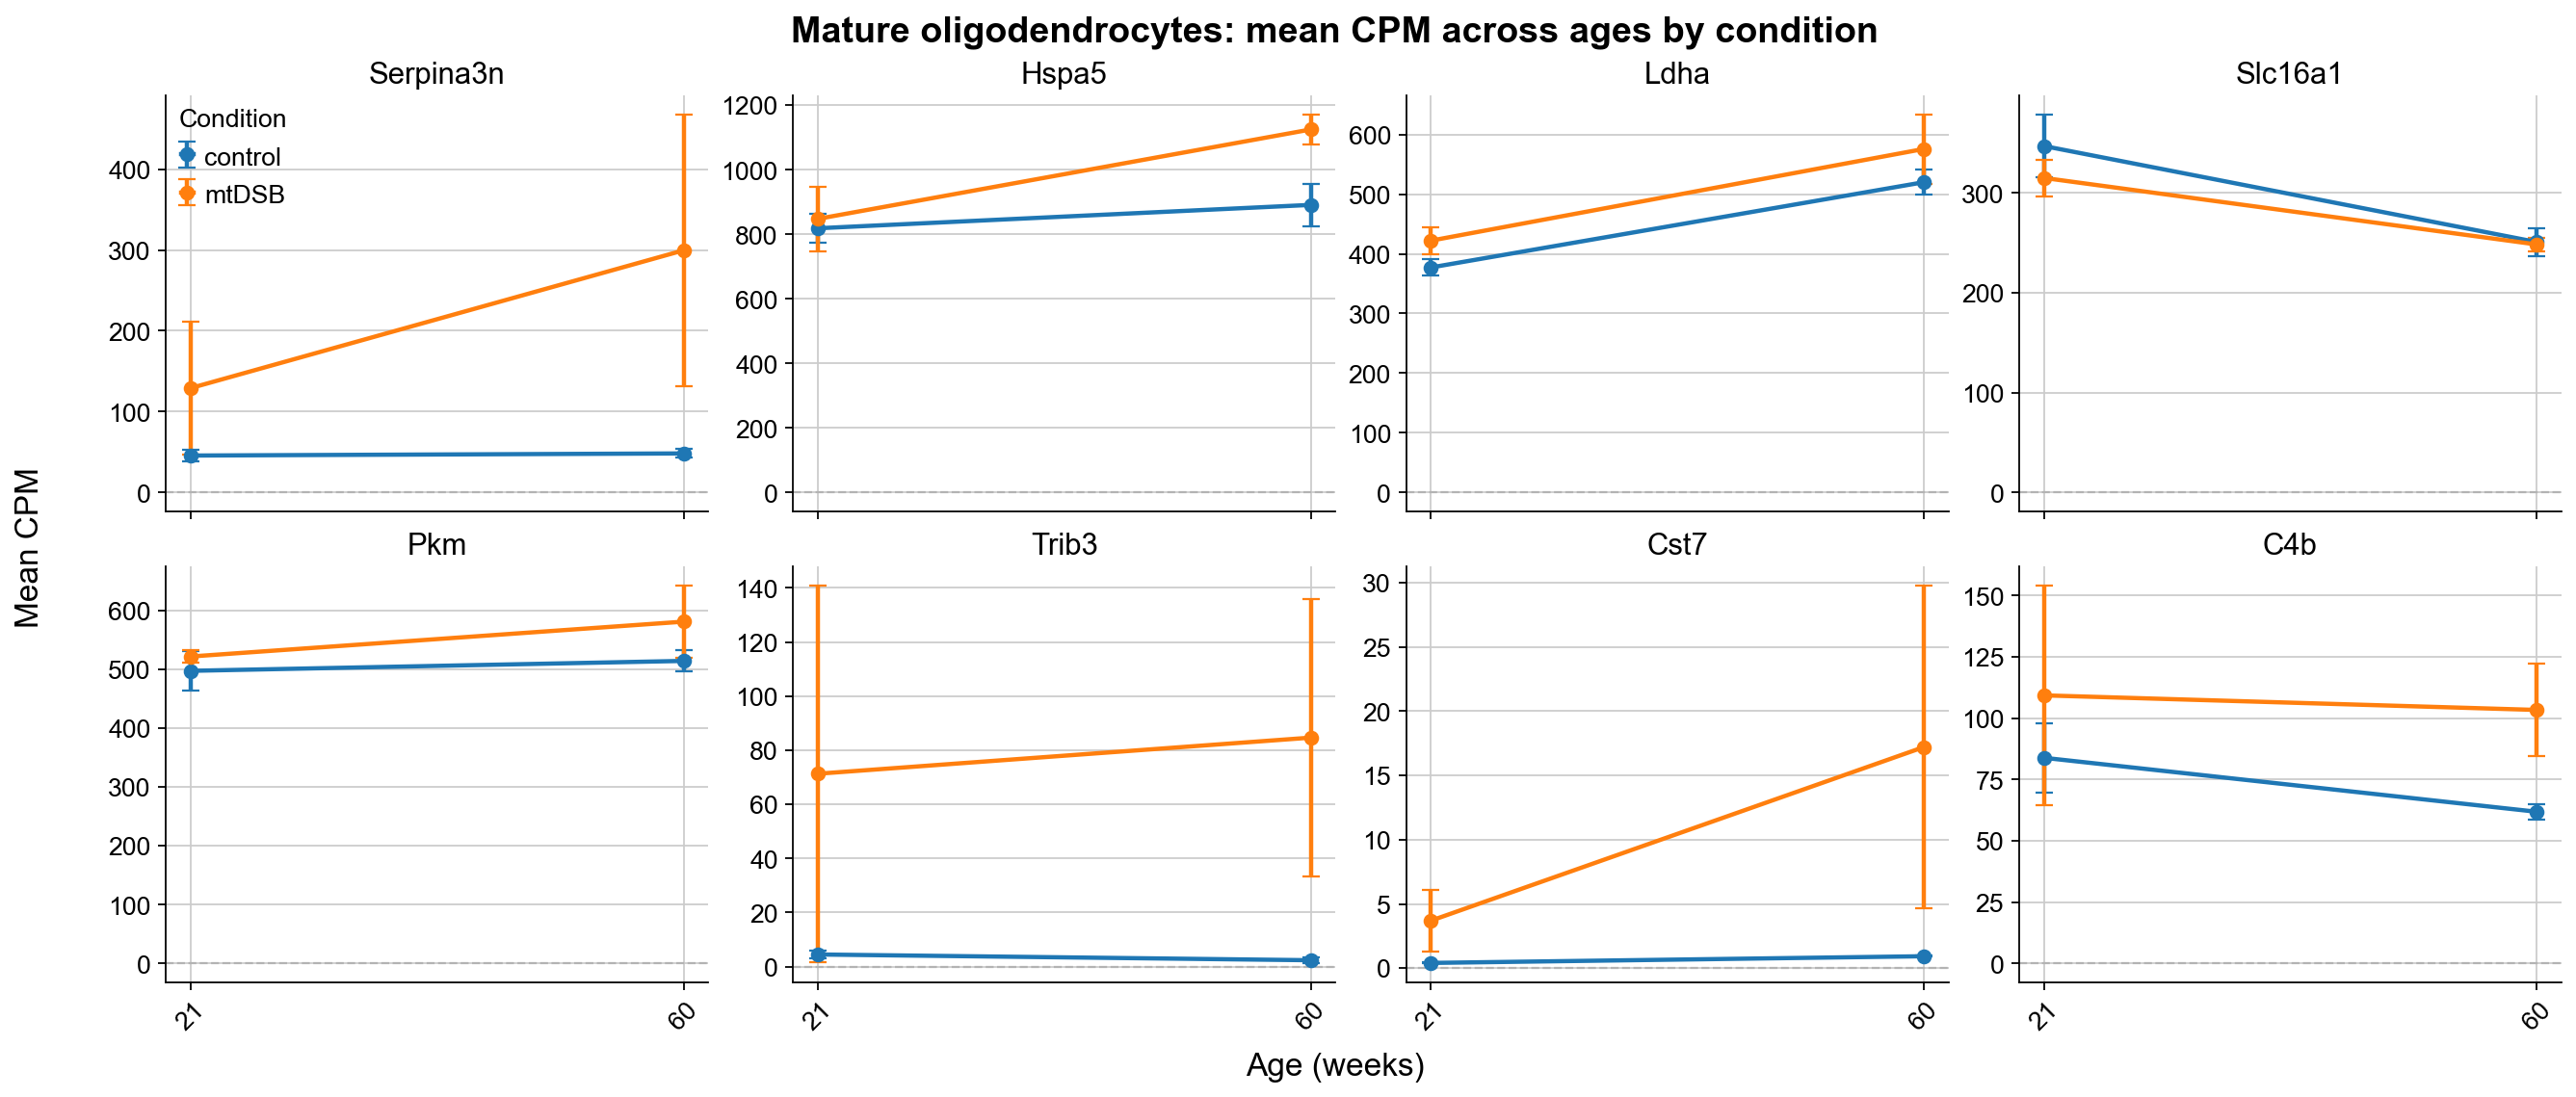

In [273]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_expression_by_condition_grid(
    pb,
    ct="Mature oligodendrocytes",
    genes=genes,
    norm=True,        # CPM
    ncols=4,
    sharey=False,      # compare magnitudes across genes
    fontsize_base=14
)

In [274]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def volcano_clean(
    res_df,
    lfc_col="log2FC_mtDSB_vs_control",
    padj_col="padj_mtDSB_vs_control",
    title="mtDSB vs control (60 wks)",
    lfc_thr=1.0, q=0.05,
    label_top_fdr=10,            # how many best FDR genes to label
    label_top_abs_lfc=10,        # plus how many most extreme |LFC| to label
    max_labels=20,               # hard cap on labels
    highlight_genes=None,        # force-label these even if not in top sets
    figsize=(9,7), fontsize=13,
    pretty_print=True,           # <-- NEW: print a compact table
    to_csv_path=None             # <-- NEW: save that table as CSV if path given
):
    # --- prep ---
    df = (res_df.copy()
                 .replace([np.inf, -np.inf], np.nan)
                 .dropna(subset=[lfc_col, padj_col]))
    df["neglog10q"] = -np.log10(df[padj_col].clip(lower=1e-300))
    sig = (df[padj_col] < q) & (df[lfc_col].abs() >= lfc_thr)

    # ranks for selection/debug
    df["rank_fdr"] = df[padj_col].rank(method="dense")
    df["rank_abs_lfc"] = df[lfc_col].abs().rank(ascending=False, method="dense")

    # --- choose labels ---
    idx_fdr = df.sort_values(padj_col).head(label_top_fdr).index
    idx_lfc = df.reindex(df[lfc_col].abs().sort_values(ascending=False)
                         .head(label_top_abs_lfc).index).index
    pick = set(idx_fdr).union(set(idx_lfc))
    if highlight_genes:
        pick.update(set(df.index.intersection(highlight_genes)))
    if len(pick) > max_labels:
        pick = set(df.loc[list(pick)].sort_values("neglog10q", ascending=False)
                   .head(max_labels).index)

    # --- build pretty table of the picked genes ---
    picked_df = (df.loc[sorted(pick, key=lambda g: (df.at[g, padj_col], -abs(df.at[g, lfc_col]))) ,
                       [lfc_col, padj_col, "neglog10q", "rank_fdr", "rank_abs_lfc"]]
                   .rename(columns={
                       lfc_col: "log2FC",
                       padj_col: "padj",
                       "neglog10q": "-log10(FDR)"
                   }))
    picked_df.index.name = "gene"

    if pretty_print:
        # concise, aligned print
        print("\n=== Important genes (labeled on plot) ===")
        print(picked_df.round({"log2FC":3, "padj":3, "-log10(FDR)":2}).to_string())

    if to_csv_path:
        picked_df.to_csv(to_csv_path)

    # --- plot ---
    plt.figure(figsize=figsize, dpi=150)
    # background
    plt.scatter(df[lfc_col], df["-log10(FDR)"] if "-log10(FDR)" in df.columns else df["neglog10q"],
                s=16, alpha=0.35, color="lightgrey", label="not sig")
    # significant up/down
    up = df[sig & (df[lfc_col] > 0)]
    dn = df[sig & (df[lfc_col] < 0)]
    plt.scatter(up[lfc_col], up["neglog10q"], s=28, color="#d73027", label="Up (sig)")
    plt.scatter(dn[lfc_col], dn["neglog10q"], s=28, color="#4575b4", label="Down (sig)")

    # thresholds
    plt.axvline(+lfc_thr, ls="--", color="k", lw=1)
    plt.axvline(-lfc_thr, ls="--", color="k", lw=1)
    plt.axhline(-np.log10(q), ls="--", color="k", lw=1)

    plt.xlabel("log₂ fold change (mtDSB vs control)", fontsize=fontsize)
    plt.ylabel("-log₁₀(FDR)", fontsize=fontsize)
    plt.title(title, fontsize=fontsize+2, pad=10)

    # labels with repulsion/arrows
    texts = []
    try:
        from adjustText import adjust_text
        for g in picked_df.index:
            x, y = df.at[g, lfc_col], df.at[g, "neglog10q"]
            t = plt.text(x, y, g, fontsize=fontsize-3, va="bottom", ha="center")
            texts.append(t)
            plt.scatter([x],[y], s=40, edgecolor="black", linewidth=0.6, zorder=4)
        adjust_text(
            texts,
            only_move={'points':'y', 'text':'xy'},
            expand_points=(1.2, 1.4),
            expand_text=(1.1, 1.2),
            arrowprops=dict(arrowstyle="-", lw=0.8, color="0.25"),
        )
    except ImportError:
        for g in picked_df.index:
            x, y = df.at[g, lfc_col], df.at[g, "neglog10q"]
            dx = 0.15 if x >= 0 else -0.15
            dy = 0.25
            plt.annotate(
                g, xy=(x, y), xytext=(x+dx, y+dy),
                fontsize=fontsize-3,
                arrowprops=dict(arrowstyle="-", lw=0.8, color="0.25"),
                ha="center", va="bottom"
            )
            plt.scatter([x],[y], s=40, edgecolor="black", linewidth=0.6, zorder=4)

    plt.legend(frameon=False, fontsize=fontsize-3)
    plt.tight_layout()
    plt.show()

    # also return the table for downstream use
    return picked_df


=== Important genes (labeled on plot) ===
           log2FC   padj  -log10(FDR)  rank_fdr  rank_abs_lfc
gene                                                         
Pmch       -3.406  0.000         6.30       1.0           8.0
Gabra2      1.155  0.000         4.92       2.0         190.0
Mt2         0.694  0.000         4.53       3.0         487.0
Hcrt       -4.498  0.001         3.03       4.0           4.0
Gfap        1.254  0.006         2.24       5.0         159.0
Serpine1    3.166  0.009         2.05       6.0          12.0
Trh         1.552  0.009         2.05       6.0          98.0
Ccl3        2.859  0.026         1.58       7.0          16.0
Slc11a1     1.575  0.027         1.57       8.0          91.0
Id1         0.848  0.030         1.53       9.0         345.0
Itga5       1.812  0.037         1.43      10.0          59.0
Cercam     -0.591  0.046         1.34      11.0         633.0
Gpnmb       3.206  0.075         1.13      13.0          11.0
Trib3       5.097  0.080   

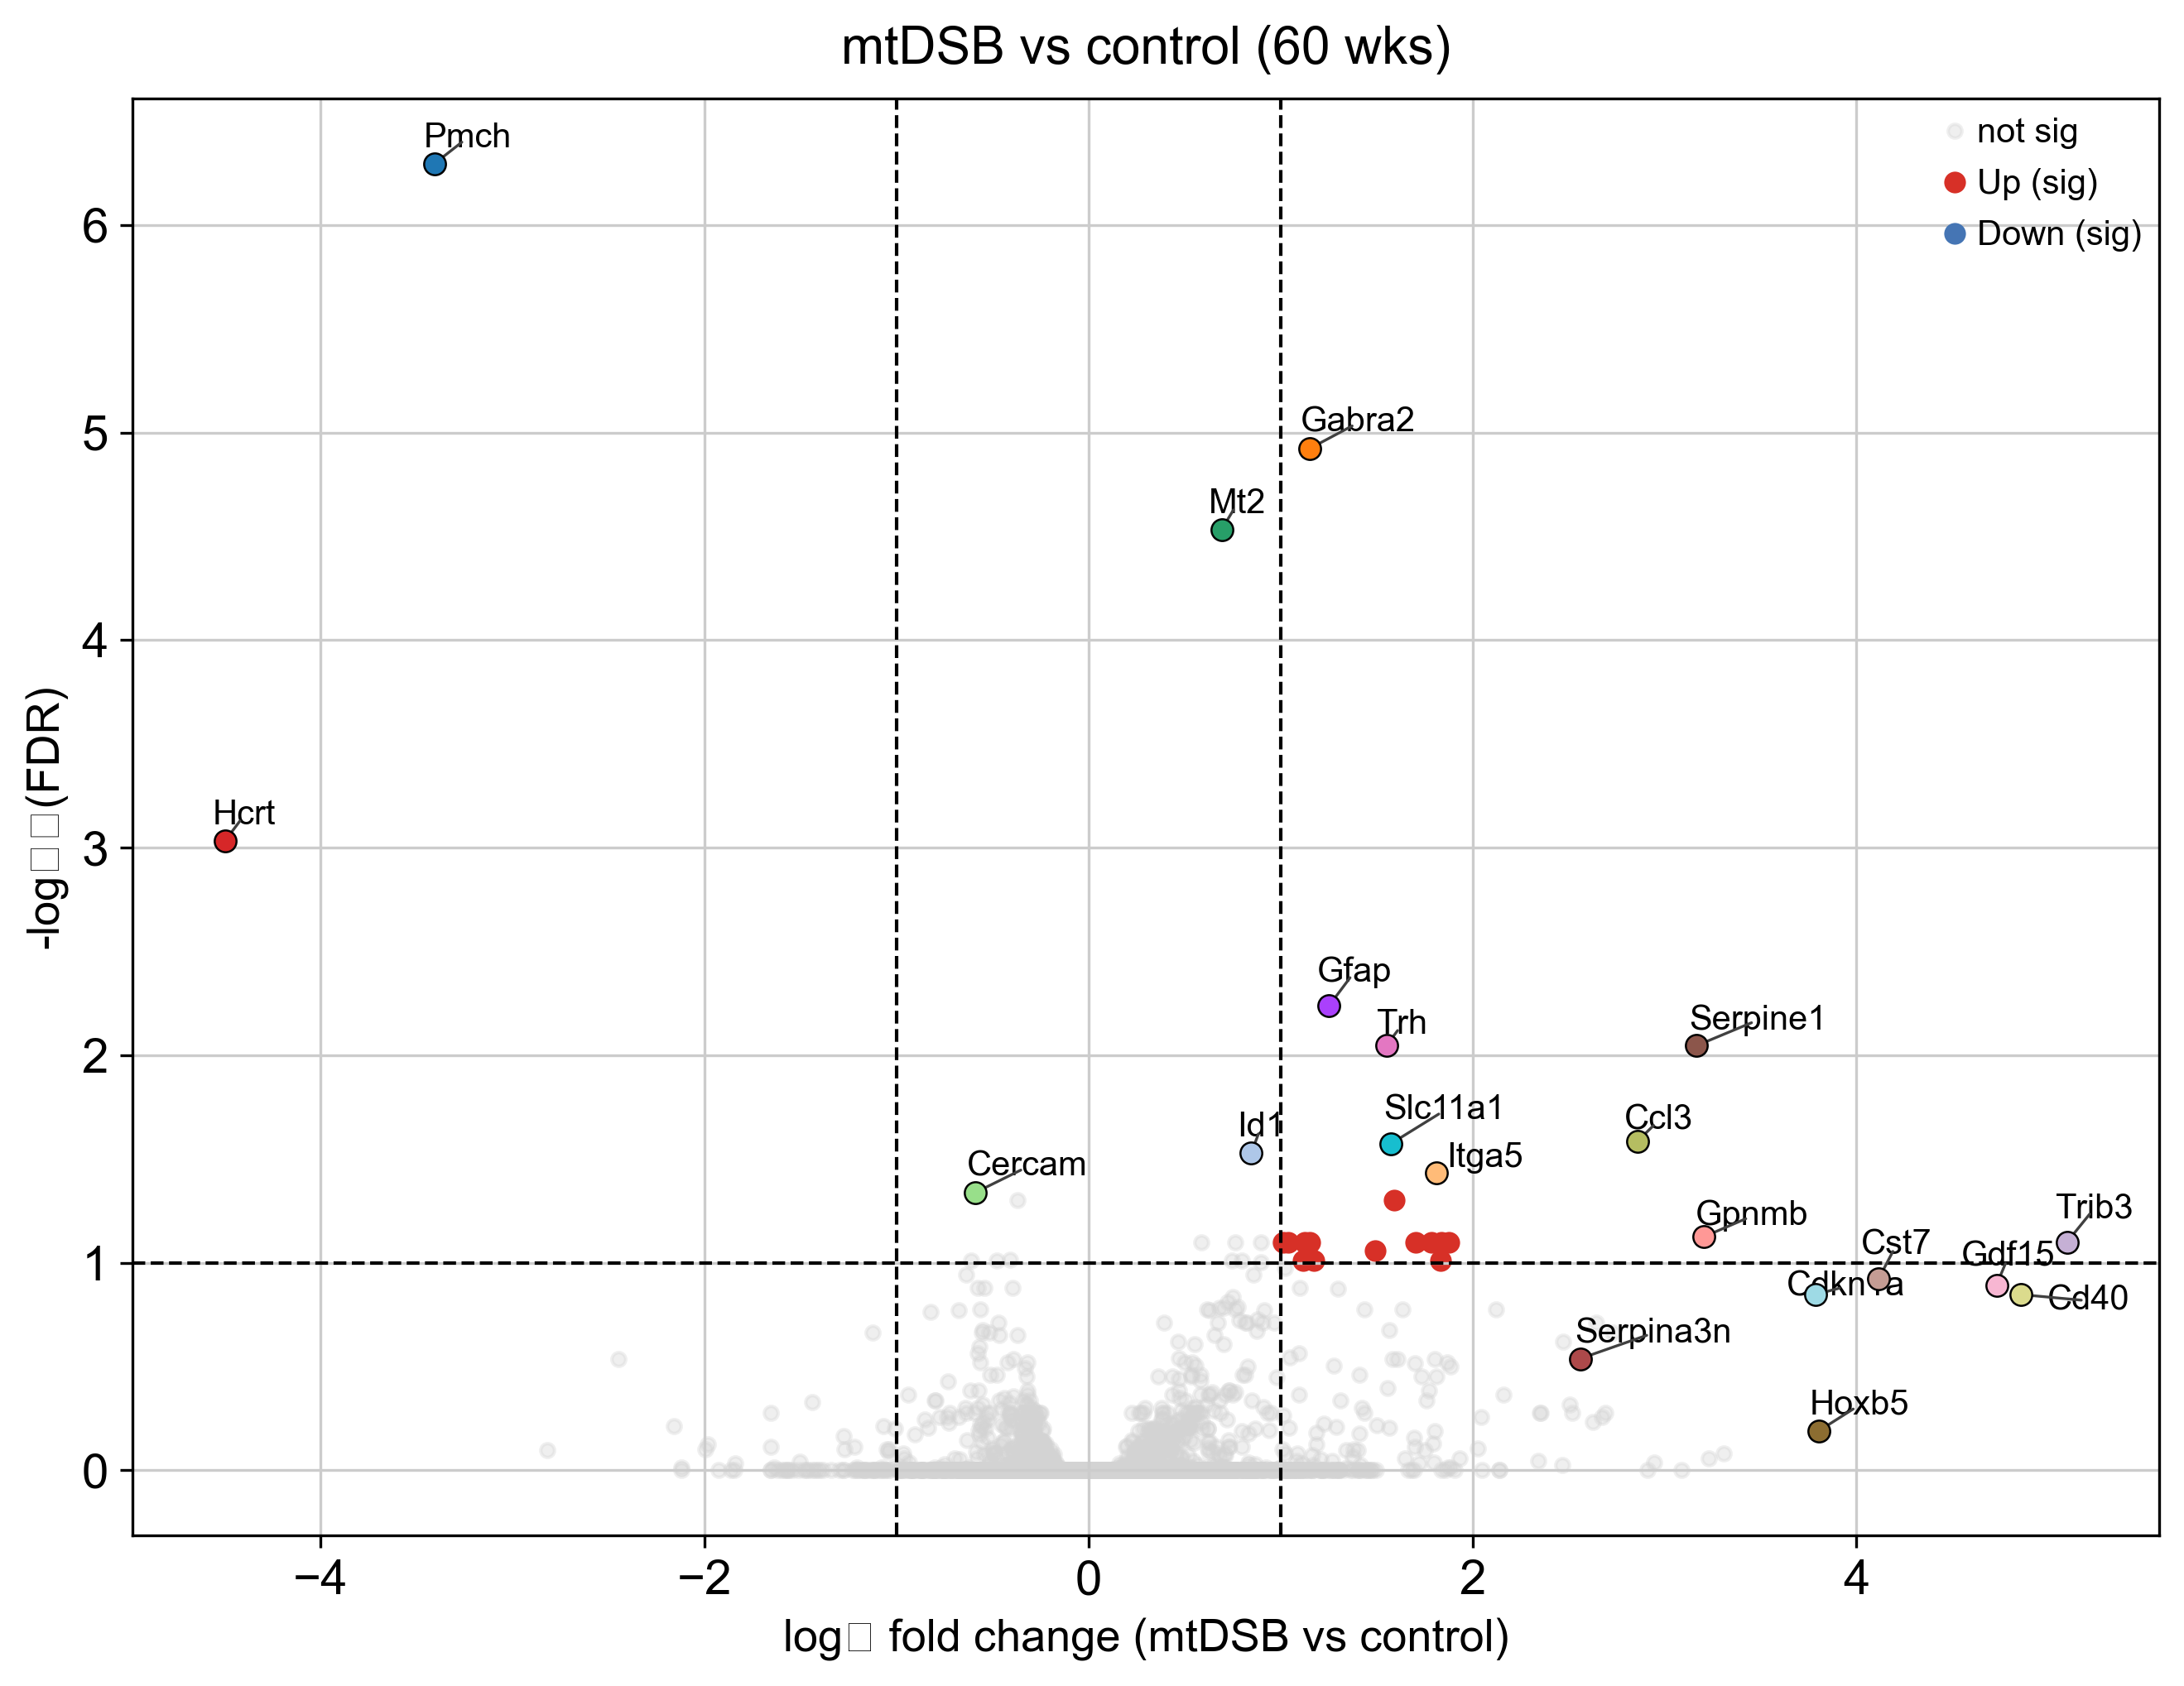

In [275]:
picked60 = volcano_clean(
    res60,
    title="mtDSB vs control (60 wks)",
    q=0.1, lfc_thr=1.0,
    label_top_fdr=12, label_top_abs_lfc=12, max_labels=20,
    highlight_genes=["Trib3", "Cst7", "Hspa5", "Gdf15", 'Serpina3n'],
    to_csv_path=None  # optional
)


=== Important genes (labeled on plot) ===
        log2FC   padj  -log10(FDR)  rank_fdr  rank_abs_lfc
gene                                                      
Fezf1    2.889  0.000         3.42       1.0          23.0
Mt1      1.129  0.000         3.32       2.0         244.0
Trh      2.008  0.010         2.00       3.0          65.0
Nkx6-2  -0.243  0.034         1.47       4.0        1545.0
Bglap2  -2.835  0.088         1.06       5.0          24.0
Trim36  -0.627  0.105         0.98       6.0         591.0
Otp      2.186  0.134         0.87       7.0          55.0
Rab10   -0.219  0.140         0.85       8.0        1673.0
Col1a1  -1.937  0.204         0.69       9.0          75.0
Col1a2  -1.433  0.204         0.69       9.0         152.0
Cst7     3.107  0.214         0.67      10.0          13.0
Bglap   -2.983  0.214         0.67      10.0          18.0
Hoxb3   -3.693  0.422         0.37      13.0           9.0
Hcrt     4.198  0.435         0.36      14.0           3.0
Hoxb5   -5.00

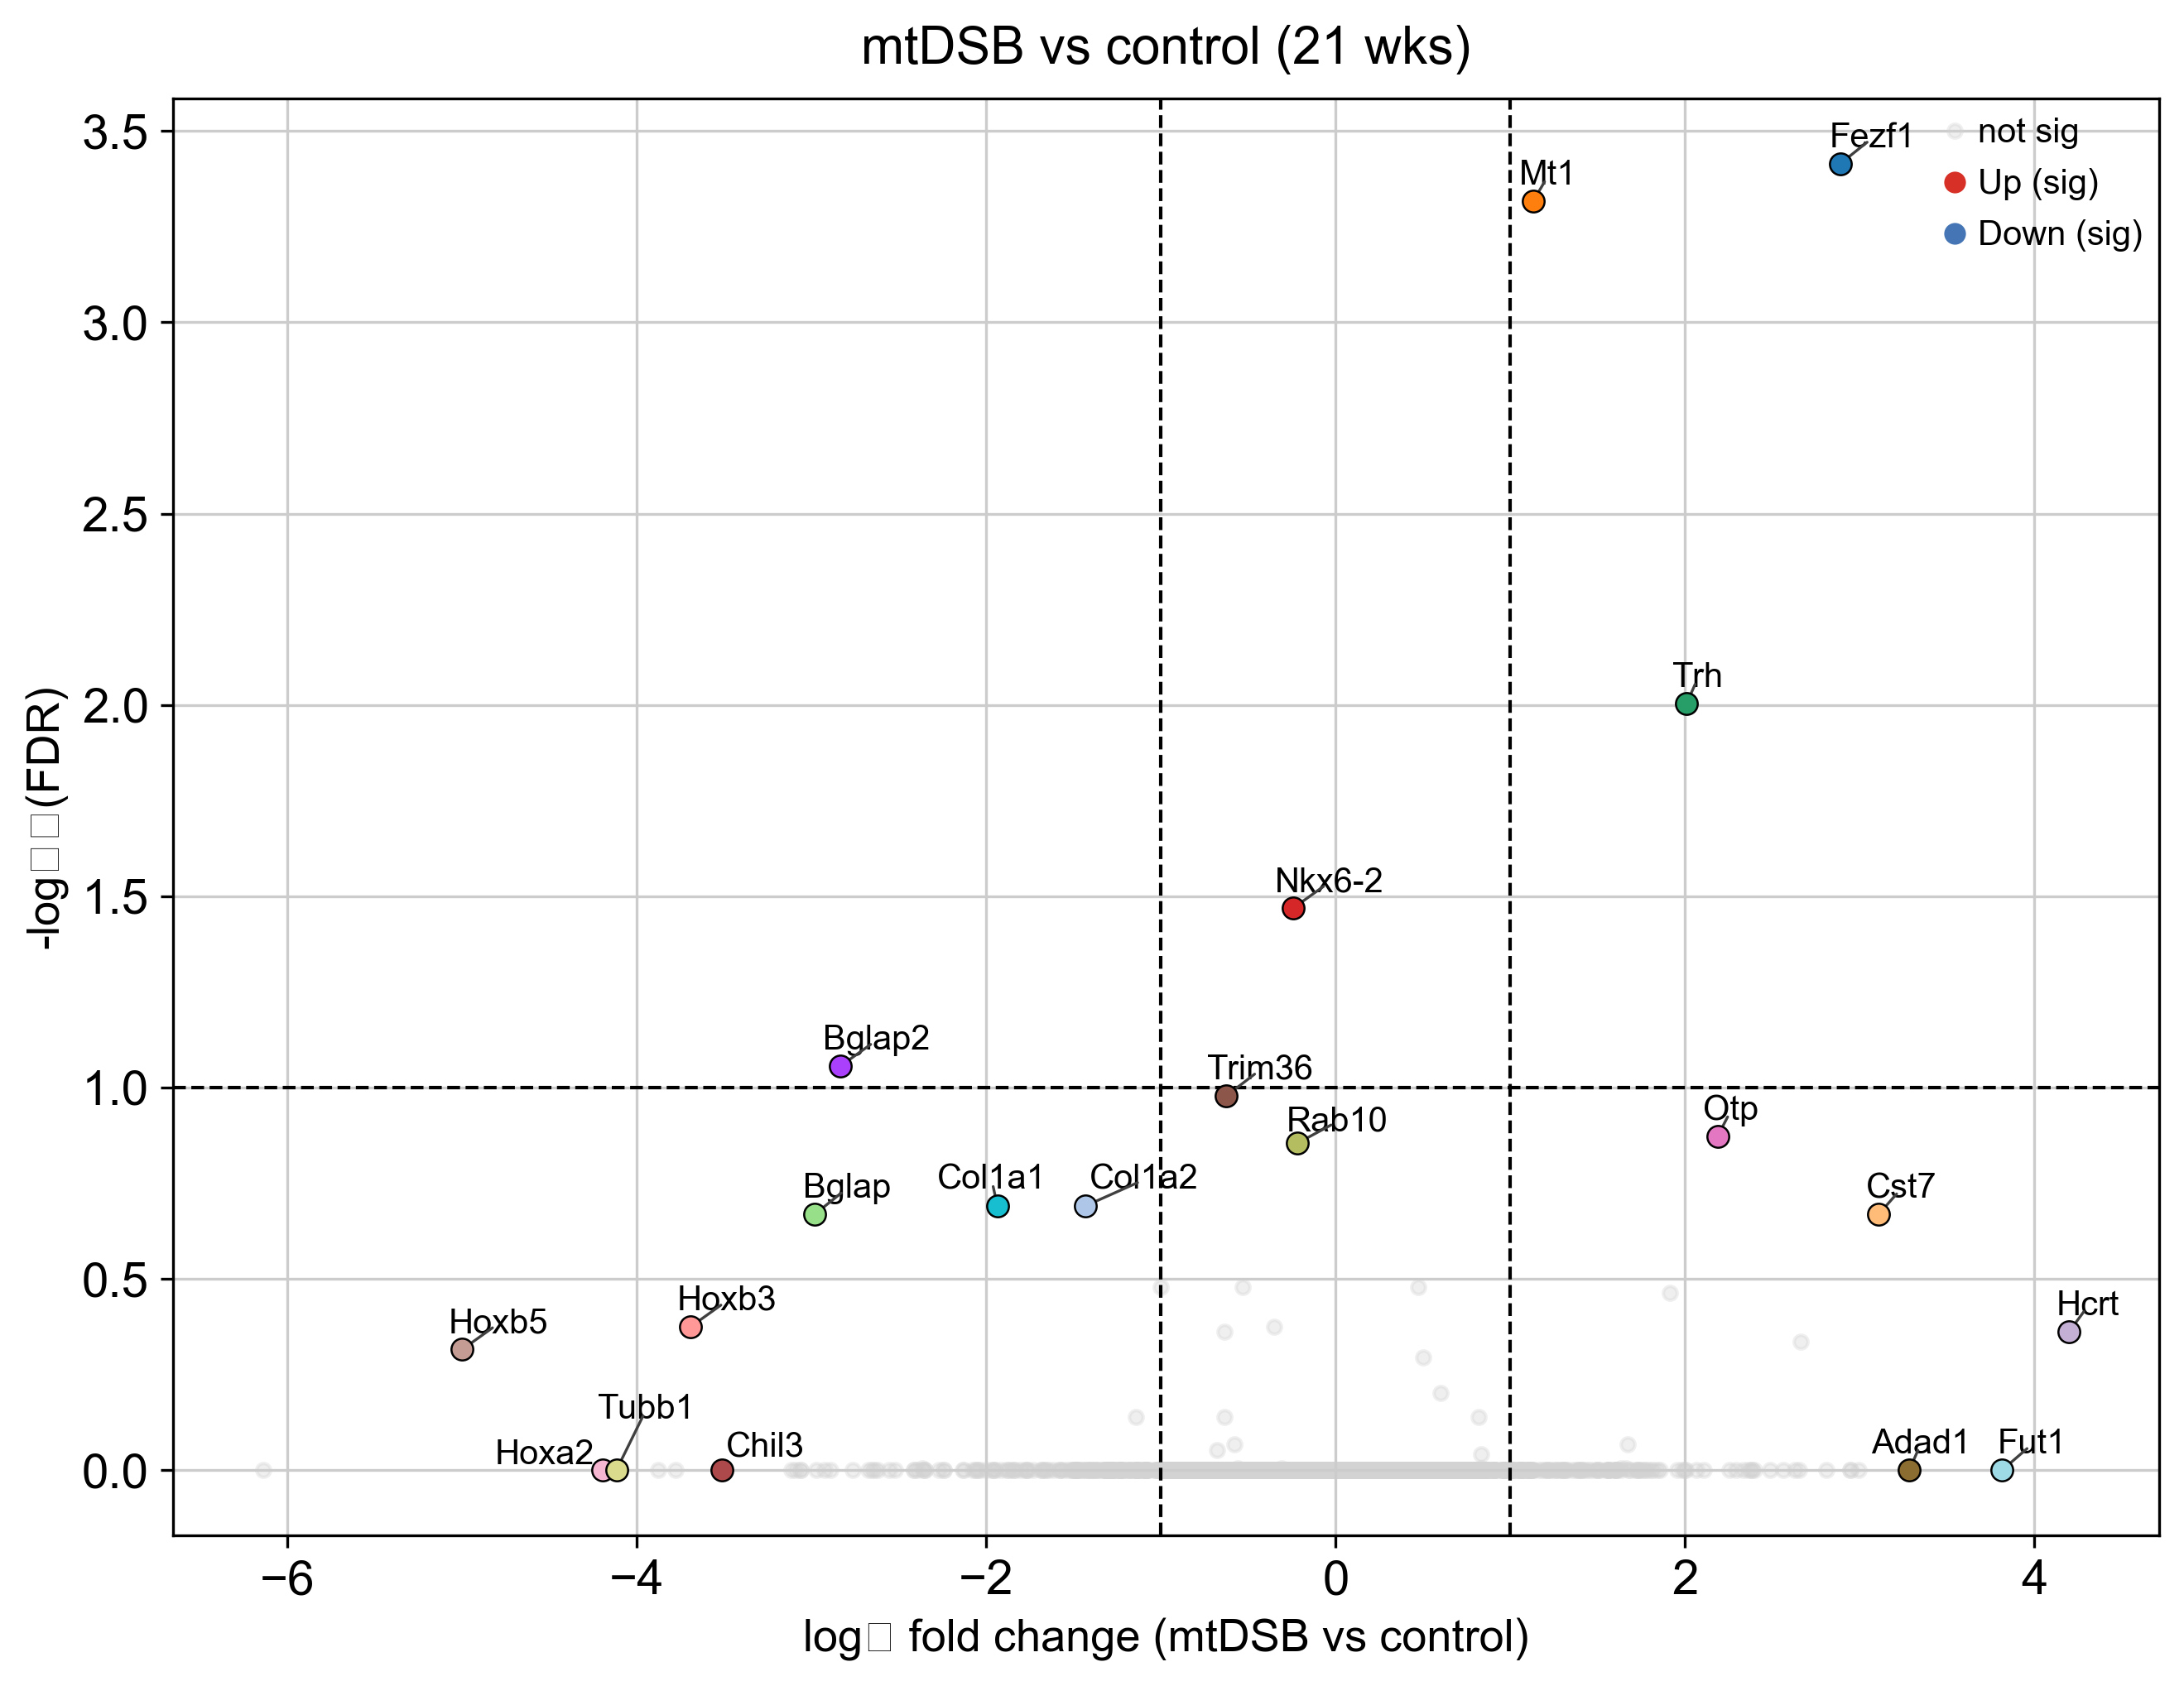

In [276]:
picked21 = volcano_clean(
    res21,
    title="mtDSB vs control (21 wks)",
    q=0.1, lfc_thr=1.0,
    label_top_fdr=12, label_top_abs_lfc=12, max_labels=20,
    highlight_genes=["Trib3", "Cst7", "Hspa5", "Gdf15", 'Serpina3n'],
    to_csv_path=None  # optional
)

In [277]:
import numpy as np
import pandas as pd

def pick_top_per_age(
    res21, res60,
    lfc_col="log2FC_mtDSB_vs_control",
                        padj_col="pvalue_mtDSB_vs_control",
    q=0.05,
    top_n_each=20,
    age_specific=False,        # keep genes sig at one age but not the other
    alpha_lfc=1.0,             # weight for |LFC|
    beta_p=0.5,                # weight for -log10(FDR); set to 0 for LFC-only
    max_labels=None
):
    """Pick top genes per age with LFC-prioritized scoring."""
    # Auto-detect columns if not supplied
    if lfc_col is None:
        lfc_col = "log2FoldChange" if "log2FoldChange" in res21.columns else \
                  [c for c in res21.columns if c.lower().startswith("log2fc")][0]
    if padj_col is None:
        padj_col = "padj" if "padj" in res21.columns else \
                  [c for c in res21.columns if c.lower().startswith("padj") or "fdr" in c.lower()][0]

    genes = res21.index.intersection(res60.index)
    A = res21.loc[genes, [lfc_col, padj_col]].rename(columns={lfc_col:"lfc21", padj_col:"padj21"})
    B = res60.loc[genes, [lfc_col, padj_col]].rename(columns={lfc_col:"lfc60", padj_col:"padj60"})
    df = A.join(B).replace([np.inf, -np.inf], np.nan).dropna()

    # Significance masks (FDR-based)
    sig21 = df["padj21"] < q
    sig60 = df["padj60"] < q

    # Scoring with LFC priority
    def score_part(lfc, padj):
        lfc_term = np.abs(lfc) ** alpha_lfc
        p_term = (-np.log10(np.clip(padj, 1e-300, 1.0))) ** beta_p
        return lfc_term * p_term

    s21 = score_part(df["lfc21"], df["padj21"])
    s60 = score_part(df["lfc60"], df["padj60"])

    # Rank within each age among significant genes (fallback to all if none)
    pool21 = df.loc[sig21] if sig21.any() else df
    pool60 = df.loc[sig60] if sig60.any() else df

    top21 = pool21.assign(score=s21.loc[pool21.index]).sort_values("score", ascending=False).head(top_n_each)
    top60 = pool60.assign(score=s60.loc[pool60.index]).sort_values("score", ascending=False).head(top_n_each)

    if age_specific:
        top21 = top21.loc[~sig60.reindex(top21.index, fill_value=False)]
        top60 = top60.loc[~sig21.reindex(top60.index, fill_value=False)]

    picks = list(pd.Index(top21.index).union(top60.index))
    if max_labels:
        smax = pd.DataFrame({"s21": s21, "s60": s60})
        smax["smax"] = smax[["s21","s60"]].max(axis=1)
        picks = smax.loc[picks].sort_values("smax", ascending=False).head(max_labels).index.tolist()

    return picks, top21.index.tolist(), top60.index.tolist()

In [317]:
def pick_top_per_age(
    res21, res60,
    lfc_col=None, padj_col=None,
    q=0.05, top_n_each=20, age_specific=False,
    alpha_lfc=1.0, beta_p=0.5,
    max_labels=None,
    force_top_abs_lfc_each=5,   # NEW: always include N largest |LFC| per age
    force_lfc_min=2.0           # only force-add if |LFC| >= this
):
    import numpy as np, pandas as pd
    if lfc_col is None:
        lfc_col = "log2FoldChange" if "log2FoldChange" in res21.columns else \
                  [c for c in res21.columns if c.lower().startswith("log2fc")][0]
    if padj_col is None:
        padj_col = "padj" if "padj" in res21.columns else \
                  [c for c in res21.columns if c.lower().startswith("padj") or "fdr" in c.lower()][0]

    genes = res21.index.intersection(res60.index)
    A = res21.loc[genes, [lfc_col, padj_col]].rename(columns={lfc_col:"lfc21", padj_col:"padj21"})
    B = res60.loc[genes, [lfc_col, padj_col]].rename(columns={lfc_col:"lfc60", padj_col:"padj60"})
    df = A.join(B).replace([np.inf, -np.inf], np.nan).dropna()

    sig21 = df["padj21"] < q
    sig60 = df["padj60"] < q

    def score_part(lfc, padj):
        l = np.abs(lfc) ** alpha_lfc
        p = (-np.log10(np.clip(padj, 1e-300, 1.0))) ** beta_p
        return l * p

    s21 = score_part(df["lfc21"], df["padj21"])
    s60 = score_part(df["lfc60"], df["padj60"])

    pool21 = df.loc[sig21] if sig21.any() else df
    pool60 = df.loc[sig60] if sig60.any() else df

    top21 = pool21.assign(score=s21.loc[pool21.index]).sort_values("score", ascending=False).head(top_n_each)
    top60 = pool60.assign(score=s60.loc[pool60.index]).sort_values("score", ascending=False).head(top_n_each)

    if age_specific:
        top21 = top21.loc[~sig60.reindex(top21.index, fill_value=False)]
        top60 = top60.loc[~sig21.reindex(top60.index, fill_value=False)]

    # ---- FORCE-ADD large |LFC| even if padj >= q ----
    if force_top_abs_lfc_each and force_top_abs_lfc_each > 0:
        force21 = (df.loc[~sig21 & (df["lfc21"].abs() >= force_lfc_min), "lfc21"]
                   .abs().sort_values(ascending=False).head(force_top_abs_lfc_each)).index
        force60 = (df.loc[~sig60 & (df["lfc60"].abs() >= force_lfc_min), "lfc60"]
                   .abs().sort_values(ascending=False).head(force_top_abs_lfc_each)).index
    else:
        force21 = force60 = pd.Index([])

    picks = list(pd.Index(top21.index).union(top60.index).union(force21).union(force60))

    if max_labels:
        smax = pd.DataFrame({"s21": s21, "s60": s60})
        smax["smax"] = smax[["s21","s60"]].max(axis=1)
        picks = smax.loc[picks].sort_values("smax", ascending=False).head(max_labels).index.tolist()

    return picks, top21.index.tolist(), top60.index.tolist()
import matplotlib.pyplot as plt
import numpy as np

def compare_lfc_scatter_colored_labels(
    res_early,
    res_late,
    lfc_col="log2FC_mtDSB_vs_control",
    padj_col="padj_mtDSB_vs_control",   # <- prefer FDR if available
    title="Oligodendrocytes: 21w vs 60w",
    highlight_genes=None,
    q=0.05,
    figsize=(8,8),
    fontsize=12,
    top_n_delta=15,          # auto-label top |ΔLFC|
    # --- NEW: point-size controls (expression)
    expr=None,               # pd.Series (index=genes) with expression (e.g., mean CPM)
    expr_col=None,           # if expression is in res_early/res_late columns (e.g. "mean_cpm_all")
    size_min=20,             # smallest dot size
    size_max=140,            # largest dot size
    use_log_expr=True,       # log1p-transform expression before scaling
    expr_quantiles=(0.05, 0.95)  # clip expression to these quantiles for robust scaling
):
    from adjustText import adjust_text

    # --- Merge results ---
    genes = res_early.index.intersection(res_late.index)
    df = (
        res_early.loc[genes, [lfc_col, padj_col] + ([expr_col] if (expr_col and expr_col in res_early.columns) else [])]
        .rename(columns={lfc_col:"lfc_21w", padj_col:"padj_21w"})
        .join(
            res_late.loc[genes, [lfc_col, padj_col] + ([expr_col] if (expr_col and expr_col in res_late.columns) else [])]
                .rename(columns={lfc_col:"lfc_60w", padj_col:"padj_60w"}),
            how="inner"
        )
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["lfc_21w","lfc_60w"])
    )

    # expression source (priority: explicit Series -> expr_col in tables -> auto-detect mean_cpm column)
    if expr is not None:
        df["expr"] = expr.reindex(df.index)
    elif expr_col and (expr_col in df.columns):
        df["expr"] = df[expr_col]
    else:
        # try to auto-pick a mean CPM stat if present
        cand = [c for c in df.columns if c.startswith("mean_cpm")]
        df["expr"] = df[cand[0]] if cand else np.nan

    # ΔLFC and significance
    df["deltaLFC"] = df["lfc_60w"] - df["lfc_21w"]
    df["sig"] = (df["padj_21w"] < q) | (df["padj_60w"] < q)

    # --- Size scaling from expression ---
    expr_vals = df["expr"].astype(float)
    if use_log_expr:
        expr_vals = np.log1p(expr_vals)  # log1p for robustness
    # robust range via quantiles
    lo, hi = np.nanquantile(expr_vals.dropna(), expr_quantiles[0]), np.nanquantile(expr_vals.dropna(), expr_quantiles[1]) if expr_vals.notna().any() else (0.0, 1.0)
    # avoid zero-width
    if hi <= lo:
        hi = lo + 1e-6
    expr_clip = np.clip(expr_vals.fillna(lo), lo, hi)
    sizes = size_min + (expr_clip - lo) * (size_max - size_min) / (hi - lo)

    # --- Plot ---
    plt.figure(figsize=figsize, dpi=150)
    sc = plt.scatter(
        df["lfc_21w"], df["lfc_60w"],
        c=df["deltaLFC"], cmap="coolwarm",
        s=sizes, alpha=0.75, edgecolor="none"
    )

    # outline significant points
    sig_df = df[df["sig"]]
    if not sig_df.empty:
        plt.scatter(
            sig_df["lfc_21w"], sig_df["lfc_60w"],
            c=sig_df["deltaLFC"], cmap="coolwarm",
            s=sizes.loc[sig_df.index],
            edgecolor="black", linewidth=0.4, alpha=0.95, zorder=3
        )

    # Axes / refs
    lim = float(np.nanmax(np.abs(df[["lfc_21w","lfc_60w"]].values))) * 1.05
    if not np.isfinite(lim) or lim == 0:
        lim = 1.0
    plt.axhline(0, color="k", ls="--", lw=1)
    plt.axvline(0, color="k", ls="--", lw=1)
    plt.plot([-lim, lim], [-lim, lim], color="k", ls=":", lw=1)
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)
    plt.xlabel("log₂FC (21 weeks)", fontsize=fontsize)
    plt.ylabel("log₂FC (60 weeks)", fontsize=fontsize)
    plt.title(title, fontsize=fontsize+2)

    # labels: union of user-supplied + top |ΔLFC|
    picks = set(df.index.intersection(highlight_genes or []))
    picks.update(df["deltaLFC"].abs().sort_values(ascending=False).head(top_n_delta).index)

    texts = []
    for g in picks:
        if g in df.index:
            x, y = df.at[g, "lfc_21w"], df.at[g, "lfc_60w"]
            t = plt.text(x, y, g, fontsize=fontsize-2, ha="center", va="center", color="black")
            texts.append(t)

    adjust_text(
        texts,
        expand_points=(1.2, 1.3),
        expand_text=(1.1, 1.2),
        arrowprops=dict(arrowstyle="-", lw=0.7, color="0.35", alpha=0.9),
        only_move={'points':'y', 'text':'xy'}
    )

    # Colorbar (ΔLFC)
    cb = plt.colorbar(sc)
    cb.set_label("Δ log₂FC (60w − 21w)", fontsize=fontsize-1)

    # Size legend (based on expression)
    # pick three nice reference sizes
    ref_vals = np.nanpercentile(df["expr"].dropna(), [20, 60, 90]) if df["expr"].notna().any() else [0.0, 1.0, 2.0]
    if use_log_expr:
        ref_labels = [f"{v:.1f} (log1p CPM)" for v in np.log1p(ref_vals)]
    else:
        ref_labels = [f"{v:.1f}" for v in ref_vals]
    ref_sizes = size_min + ( ( (np.log1p(ref_vals) if use_log_expr else ref_vals) - lo ) * (size_max - size_min) / (hi - lo) )
    for s, lbl in zip(ref_sizes, ref_labels):
        plt.scatter([], [], s=s, c="none", edgecolor="0.3", linewidth=0.8, label=lbl)
    plt.legend(title="Expression size", frameon=False, loc="upper left", fontsize=fontsize-2)

    plt.tight_layout()
    plt.show()

    return df

## Compare LFC across age and cell type

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Cxcl9,1.667987,-4.186705,2.675470,-1.564848,0.117618,0.999909,0.528079,0.416667,0.797005,0.259153,0.739424,0.316733
Hoxb5,1.605537,-4.101593,2.771600,-1.479865,0.138909,0.999909,1.036998,0.333333,0.695541,1.378454,0.695541,1.378454
Cxcl10,17.036987,4.060074,2.339613,1.735361,0.082677,0.999909,5.404955,0.750000,0.896176,9.913735,7.455173,3.354737
H19,1.477571,-3.982189,2.507478,-1.588125,0.112258,0.999909,0.434414,0.500000,0.640051,0.228778,0.640051,0.228778
Hoxa2,1.384798,-3.887753,2.825603,-1.375902,0.168852,0.999909,0.667694,0.333333,0.597705,0.737682,0.597705,0.737682
Hoxb3,2.836163,-3.858121,2.125671,-1.815014,0.069522,0.999909,1.138018,0.416667,1.142292,1.133744,1.227853,1.048184
Cldn9,1.290492,-3.824663,2.584504,-1.479844,0.138915,0.999909,0.430518,0.583333,0.688267,0.172769,0.571498,0.289538
Cxcl13,1.222688,3.748315,2.748154,1.363939,0.172587,0.999909,0.510156,0.666667,0.303333,0.716980,0.533684,0.486628
Hcrt,48.282641,3.724667,1.296497,2.872871,0.004068,0.999909,23.186766,1.000000,25.310820,21.062712,21.049848,25.323684
Egr2,2.423043,3.666409,1.844949,1.987269,0.046893,0.999909,1.189842,0.833333,0.559987,1.819696,1.062263,1.317421


,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Bcl3,9.581383,5.530043,1.623690,3.405848,6.595881e-04,1.129841e-01,2.397248,0.750000,0.307980,4.486516,1.720765,3.073731
Hoxb5,4.353530,5.406288,4.210268,1.284072,1.991168e-01,9.974254e-01,1.036998,0.333333,0.695541,1.378454,0.695541,1.378454
Hoxb3,3.308361,5.008977,4.213218,1.188872,2.344900e-01,NaN,1.138018,0.416667,1.142292,1.133744,1.227853,1.048184
Hoxa2,2.329018,4.471112,2.744107,1.629350,1.032389e-01,NaN,0.667694,0.333333,0.597705,0.737682,0.597705,0.737682
Cst7,45.997468,4.432633,1.344303,3.297346,9.760324e-04,1.196647e-01,8.599720,0.833333,1.107302,16.092137,2.392503,14.806936
Fcgr2b,134.087113,4.176207,1.151132,3.627914,2.857208e-04,7.779225e-02,29.519985,1.000000,6.085305,52.954665,15.834671,43.205298
Hcrt,77.979947,-4.094284,0.554122,-7.388783,1.481785e-13,3.025806e-10,23.186766,1.000000,25.310820,21.062712,21.049848,25.323684
Cd300lb,1.647630,3.968480,2.763751,1.435904,1.510297e-01,NaN,0.416413,0.416667,0.070091,0.762736,0.305357,0.527469
Hoxa4,1.574621,3.909212,3.213690,1.216425,2.238231e-01,NaN,0.539275,0.333333,0.446751,0.631799,0.580172,0.498378
Cybb,7.901496,3.704620,1.255836,2.949923,3.178536e-03,2.318061e-01,1.722692,0.750000,0.511727,2.933658,0.906262,2.539123


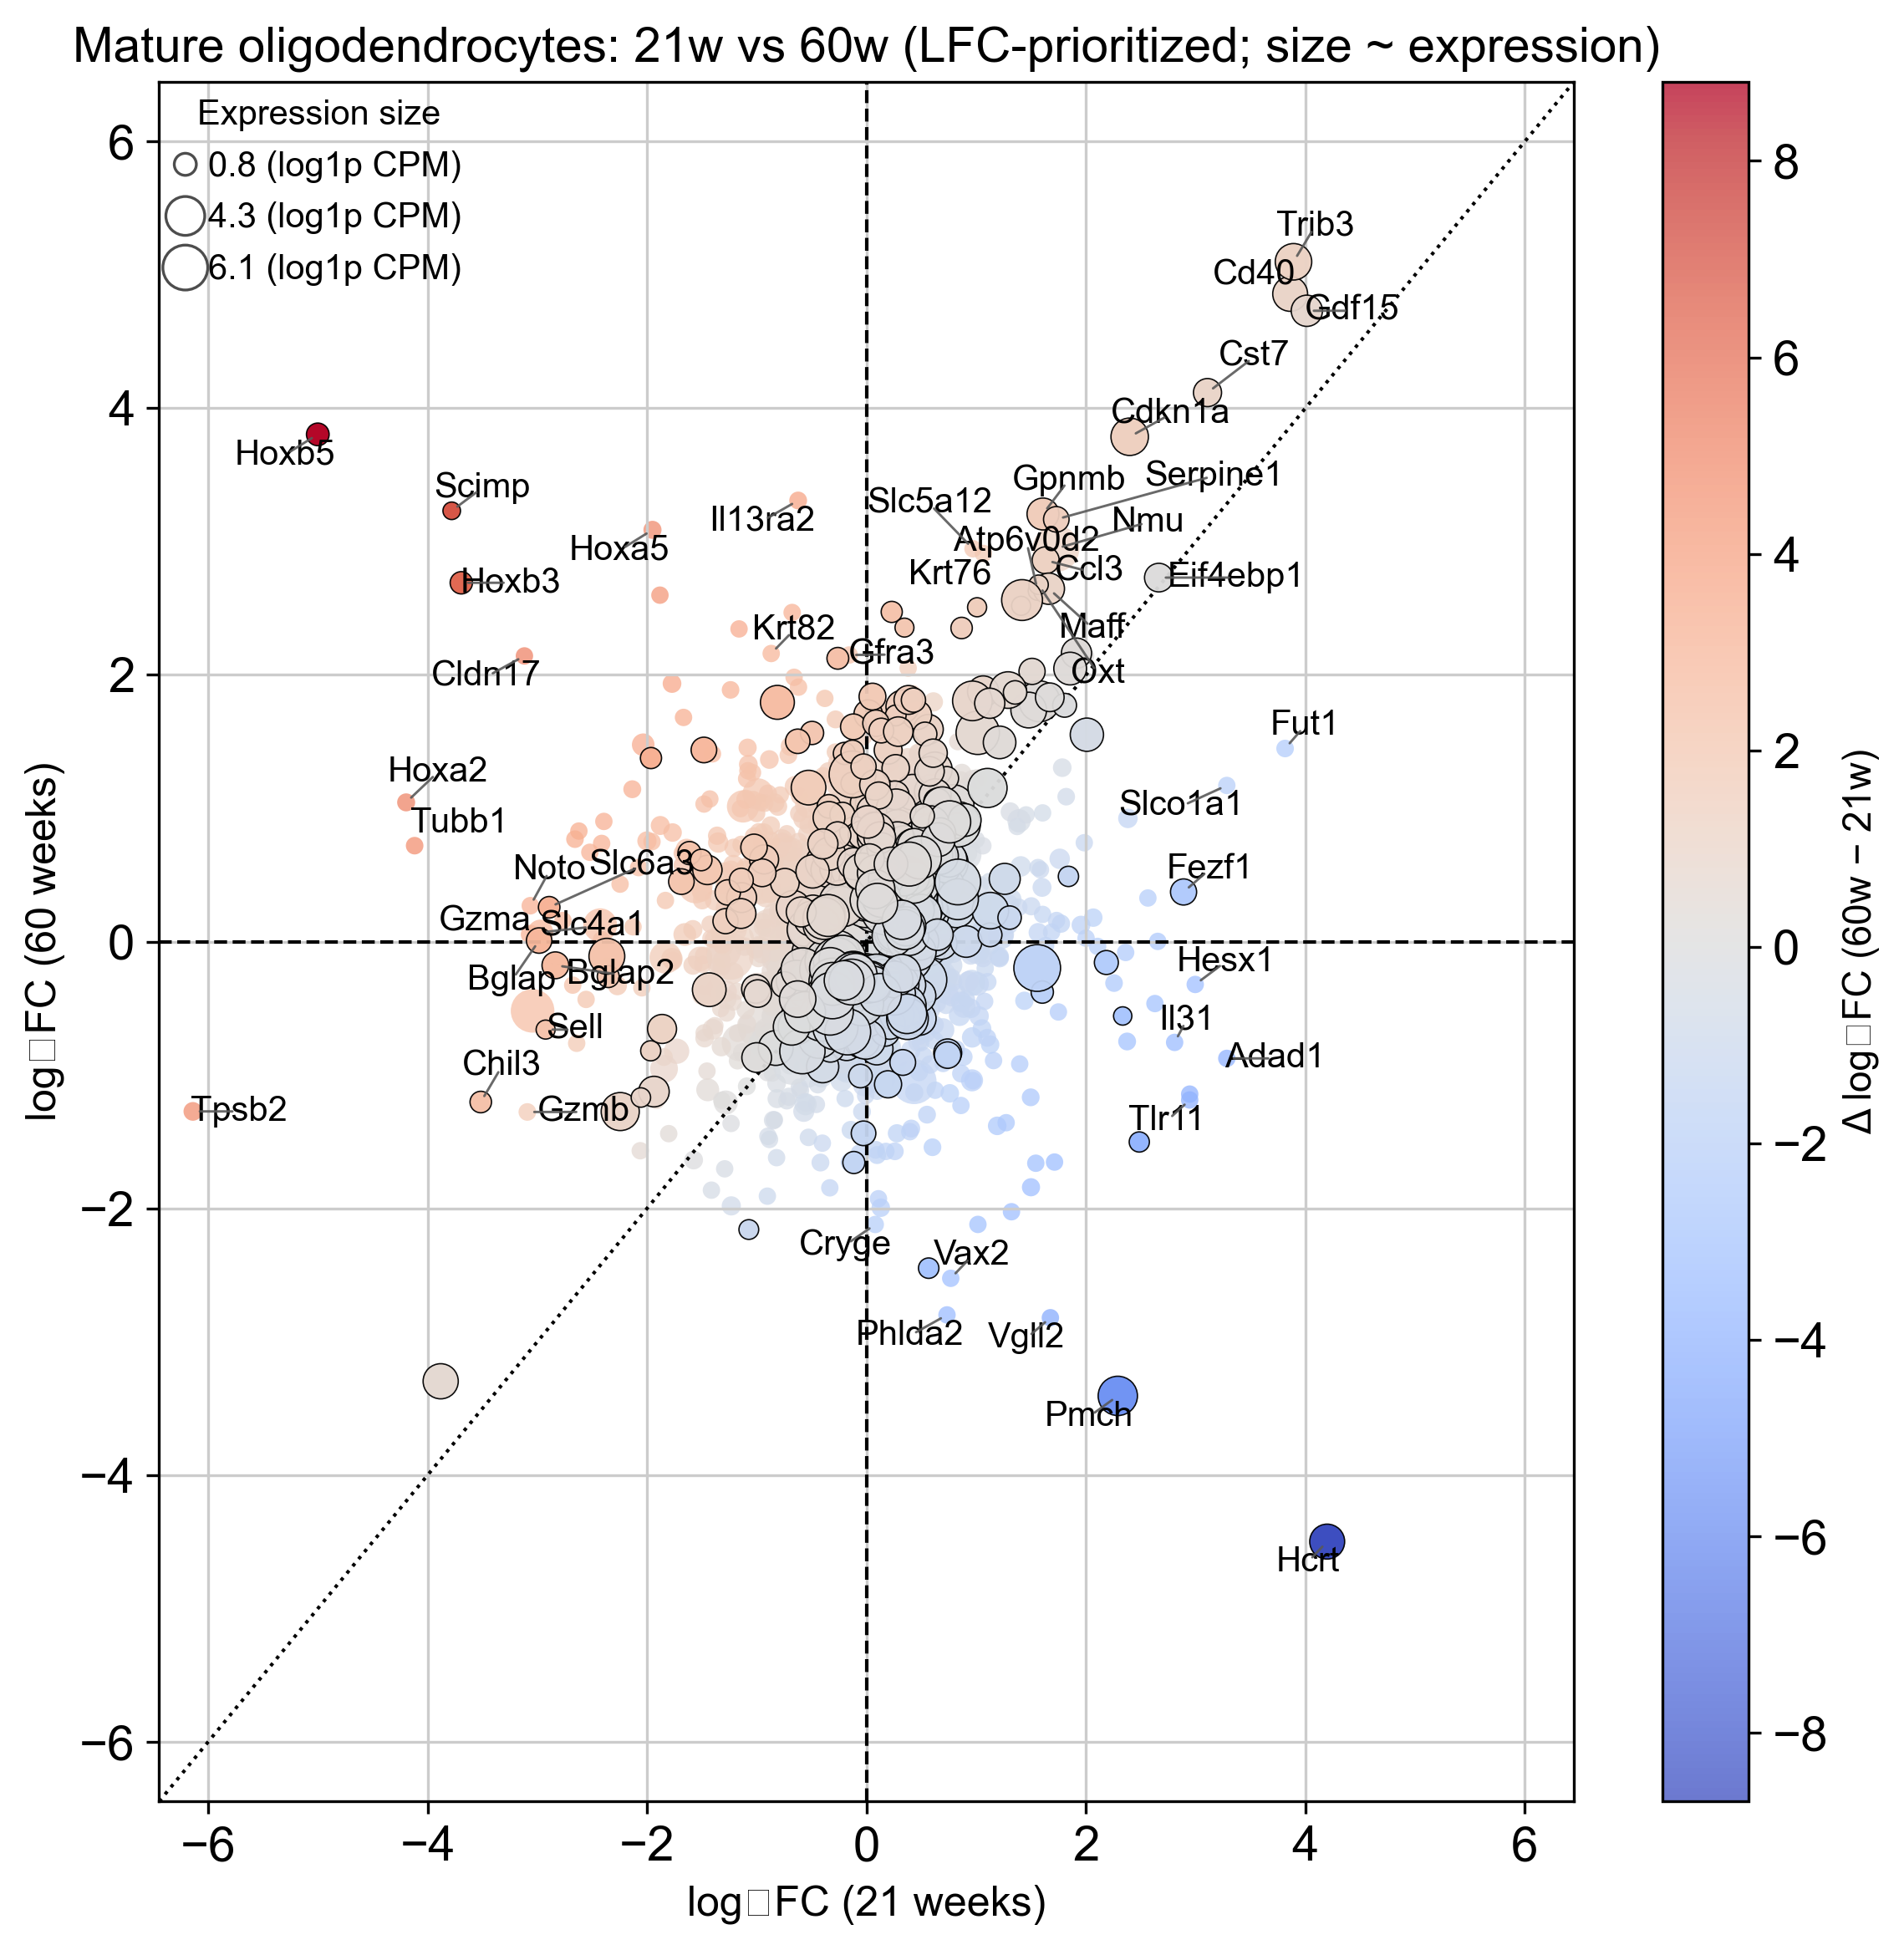

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Bglap,35.597,-2.983,0.857,-3.480,0.001,0.214,3.014,1.000,4.563,1.465,4.126,1.902
Bglap2,51.813,-2.835,0.722,-3.926,0.000,0.088,4.131,1.000,6.404,1.858,6.007,2.254
Chil3,6.417,-3.515,1.578,-2.228,0.026,1.000,1.142,0.833,1.741,0.543,0.749,1.536
Cst7,16.769,3.107,0.893,3.478,0.001,0.214,5.556,1.000,0.664,10.447,2.045,9.066
Fezf1,40.950,2.889,0.537,5.378,0.000,0.000,3.553,1.000,1.487,5.619,4.902,2.203
Fut1,2.601,3.814,1.987,1.920,0.055,1.000,0.274,0.750,0.080,0.468,0.319,0.229
Gzma,4.837,-3.063,1.618,-1.893,0.058,1.000,0.545,0.917,0.750,0.339,0.568,0.521
Gzmb,1.775,-3.091,2.379,-1.299,0.194,1.000,0.277,0.750,0.427,0.127,0.210,0.345
Hcrt,256.264,4.198,1.338,3.138,0.002,0.435,27.753,1.000,25.255,30.251,30.723,24.783
Hoxa2,3.614,-4.195,2.220,-1.890,0.059,1.000,0.337,0.583,0.485,0.189,0.425,0.249


,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Atp6v0d2,6.840,2.629,1.204,2.185,0.029,0.584,0.482,0.833,0.154,0.810,0.223,0.742
Ccl3,51.779,2.859,0.698,4.098,0.000,0.026,4.329,1.000,1.373,7.285,3.003,5.655
Cdkn1a,628.630,3.785,1.186,3.192,0.001,0.142,52.241,1.000,10.018,94.465,36.529,67.953
Cst7,82.168,4.117,1.251,3.290,0.001,0.119,5.556,1.000,0.664,10.447,2.045,9.066
Eif4ebp1,72.988,2.729,0.933,2.927,0.003,0.217,6.264,1.000,1.588,10.941,4.632,7.897
Gpnmb,165.426,3.206,0.869,3.689,0.000,0.075,13.309,1.000,3.771,22.847,8.874,17.745
Hcrt,237.986,-4.498,0.909,-4.949,0.000,0.001,27.753,1.000,25.255,30.251,30.723,24.783
Hoxa5,1.873,3.087,2.271,1.359,0.174,1.000,0.352,0.667,0.420,0.285,0.510,0.195
Hoxb3,10.870,2.691,1.161,2.318,0.020,0.530,1.422,1.000,1.747,1.097,1.727,1.117
Hoxb5,16.963,3.803,1.854,2.051,0.040,0.647,1.561,0.750,1.455,1.666,1.379,1.742


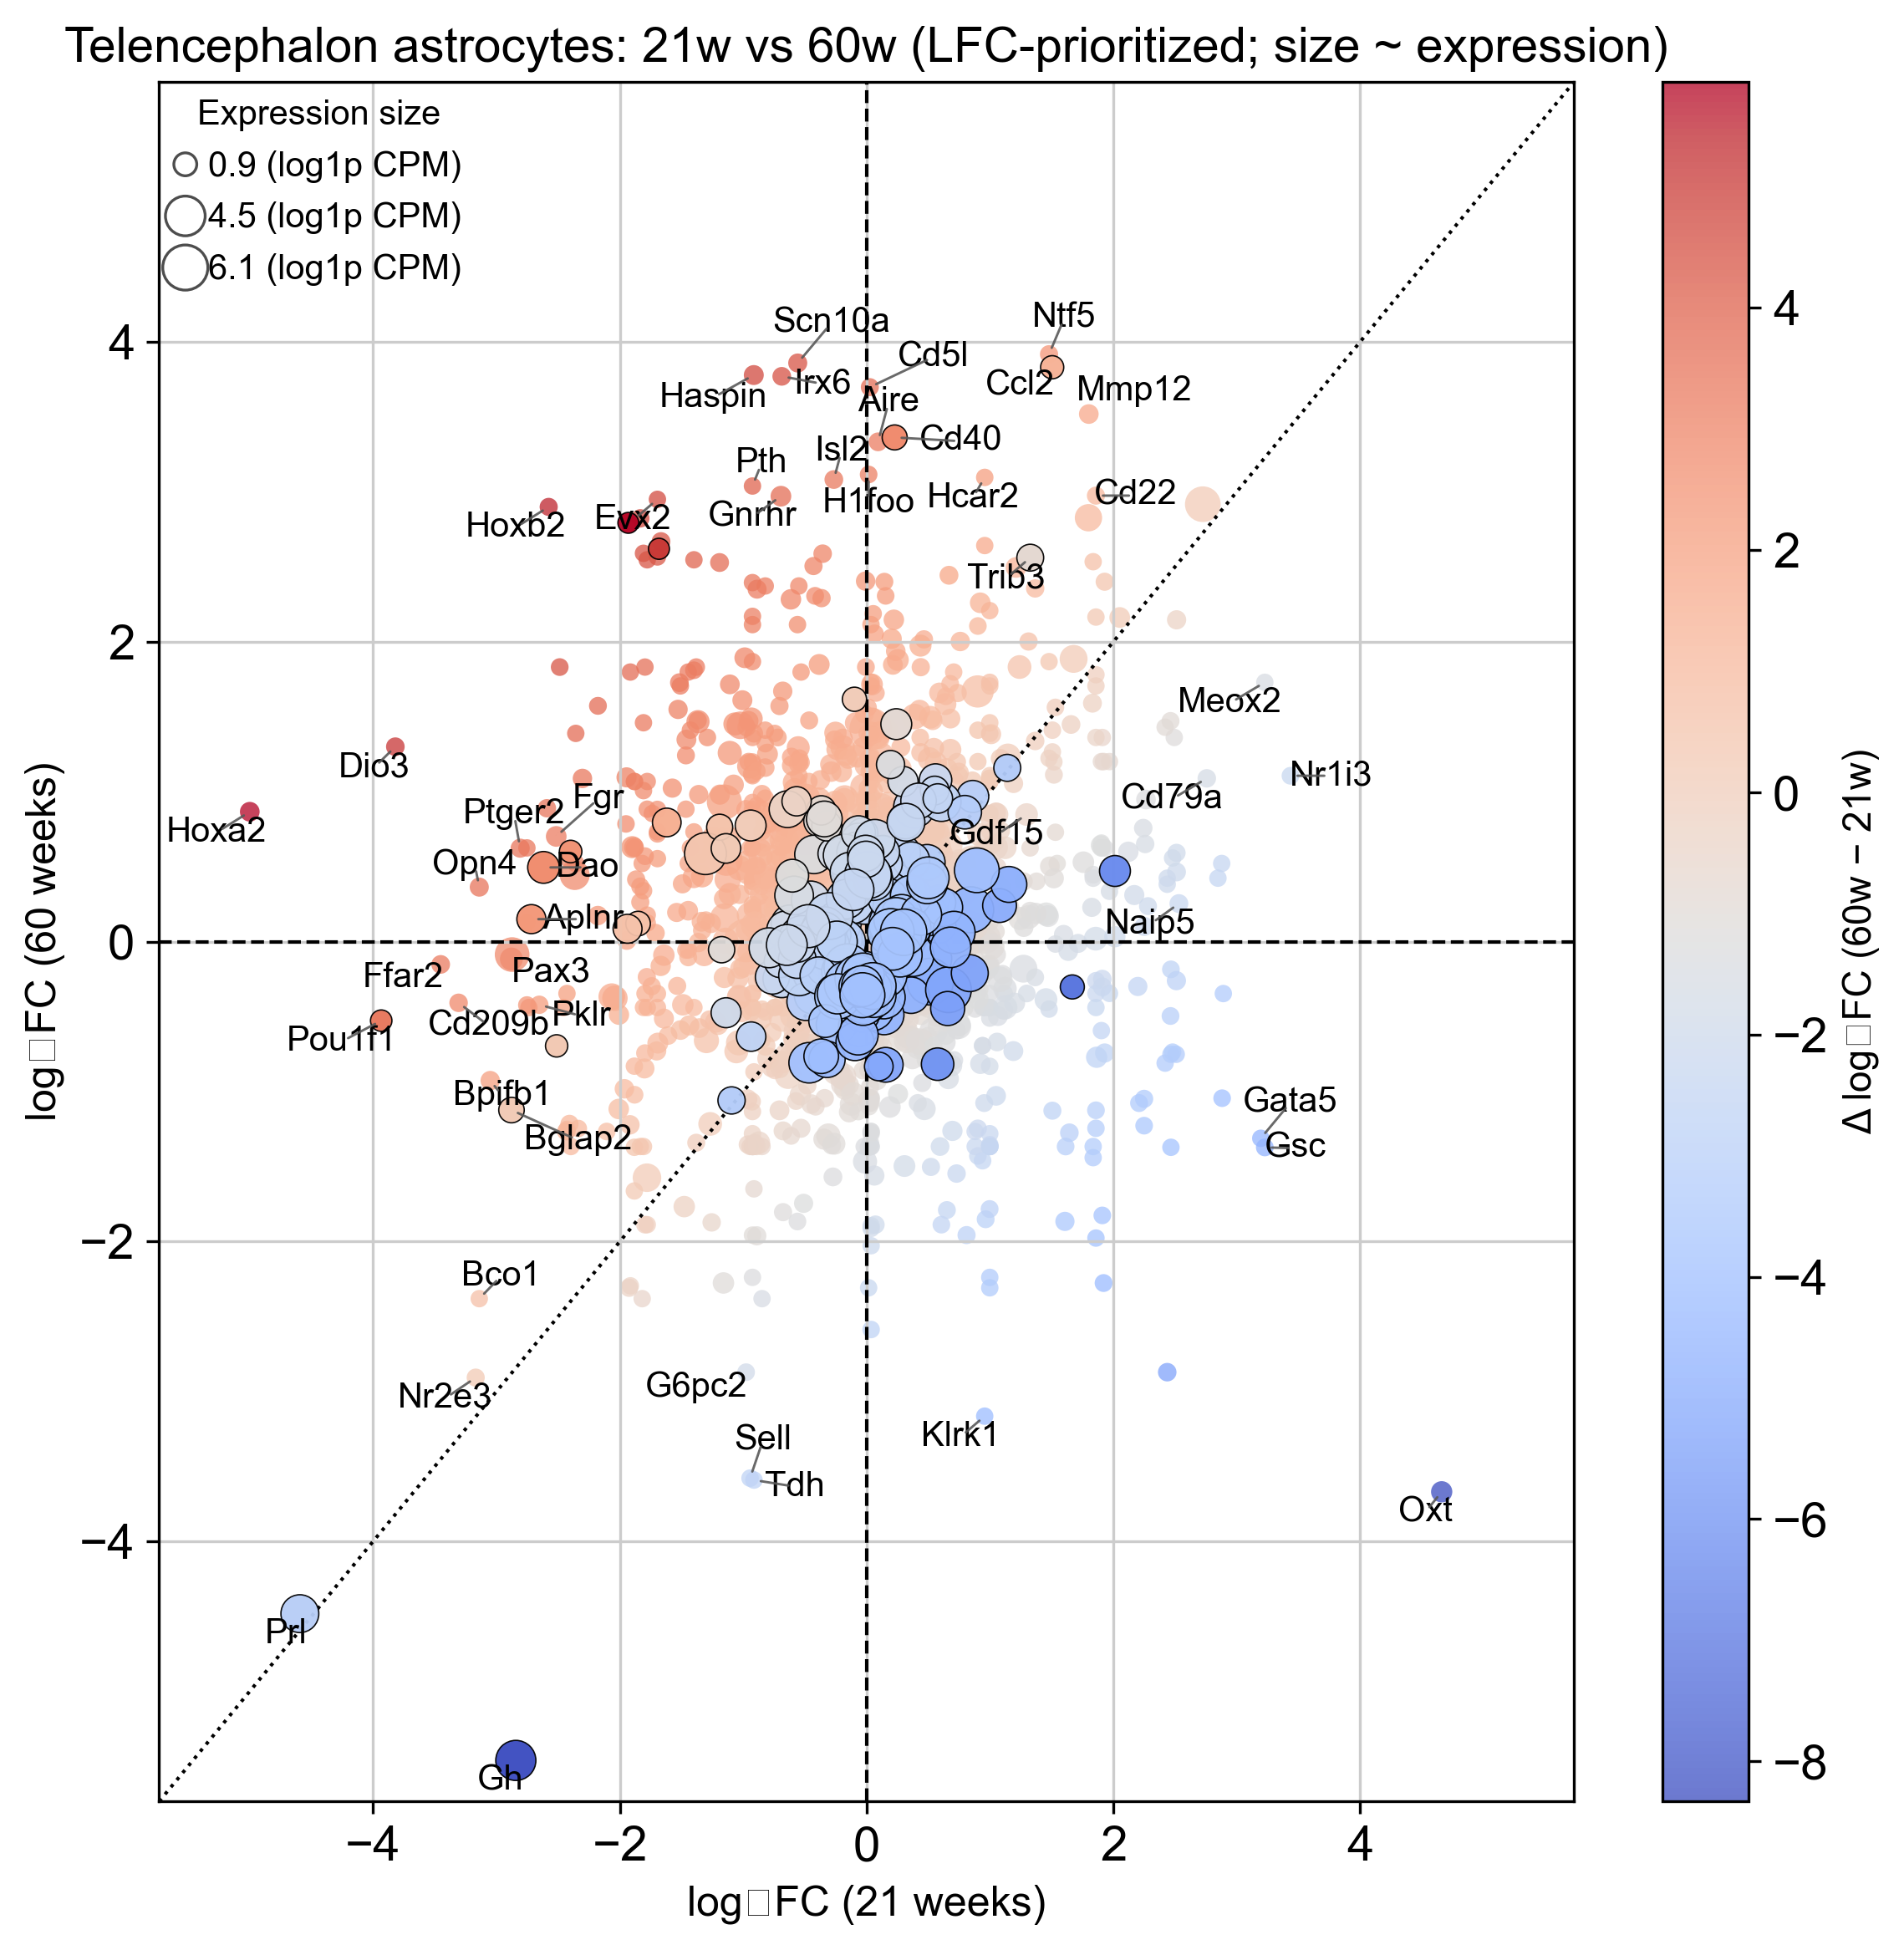

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Aplnr,30.286,-2.717,0.579,-4.690,0.000,0.014,6.510,1.000,9.784,3.236,9.092,3.927
Bglap2,14.027,-2.878,0.737,-3.906,0.000,0.083,2.844,1.000,4.721,0.967,4.216,1.472
Bpifb1,1.646,-3.051,2.453,-1.244,0.214,1.000,0.510,0.667,0.786,0.233,0.493,0.527
Cd79a,1.346,2.757,2.224,1.240,0.215,1.000,0.348,0.500,0.133,0.563,0.410,0.285
Dao,60.530,-2.618,1.031,-2.541,0.011,1.000,12.117,1.000,18.081,6.153,18.170,6.064
Dio3,1.314,-3.820,2.498,-1.529,0.126,1.000,0.368,0.667,0.492,0.245,0.395,0.342
Ffar2,1.025,-3.452,2.706,-1.276,0.202,1.000,0.380,0.750,0.554,0.206,0.309,0.450
Fgr,2.259,-2.516,1.519,-1.656,0.098,1.000,0.806,0.833,0.929,0.683,0.679,0.933
Gh,656.723,-2.843,1.691,-1.681,0.093,1.000,100.734,0.917,177.116,24.353,197.095,4.374
Gsc,0.851,3.228,2.759,1.170,0.242,1.000,0.229,0.500,0.153,0.304,0.259,0.199


,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Aire,1.086,3.334,2.533,1.316,0.188,1.000,0.393,0.667,0.243,0.542,0.514,0.272
Ccl2,6.035,3.831,1.265,3.029,0.002,0.445,1.604,0.833,0.533,2.674,1.684,1.524
Cd22,1.880,2.975,1.938,1.535,0.125,1.000,0.288,0.500,0.053,0.523,0.099,0.477
Cd40,13.087,3.363,0.957,3.515,0.000,0.172,2.541,1.000,1.087,3.994,1.759,3.322
Cd5l,1.372,3.698,2.407,1.536,0.124,1.000,0.268,0.500,0.095,0.442,0.192,0.345
Gh,17.337,-5.461,1.707,-3.200,0.001,0.327,100.734,0.917,177.116,24.353,197.095,4.374
Gnrhr,1.760,2.971,1.906,1.559,0.119,1.000,0.809,0.833,0.780,0.839,1.180,0.439
H1foo,0.906,3.116,2.619,1.190,0.234,1.000,0.215,0.500,0.101,0.330,0.204,0.226
Haspin,1.467,3.779,2.392,1.580,0.114,1.000,0.630,0.667,0.576,0.685,0.891,0.370
Hcar2,0.921,3.096,2.638,1.174,0.240,1.000,0.191,0.500,0.044,0.338,0.150,0.233


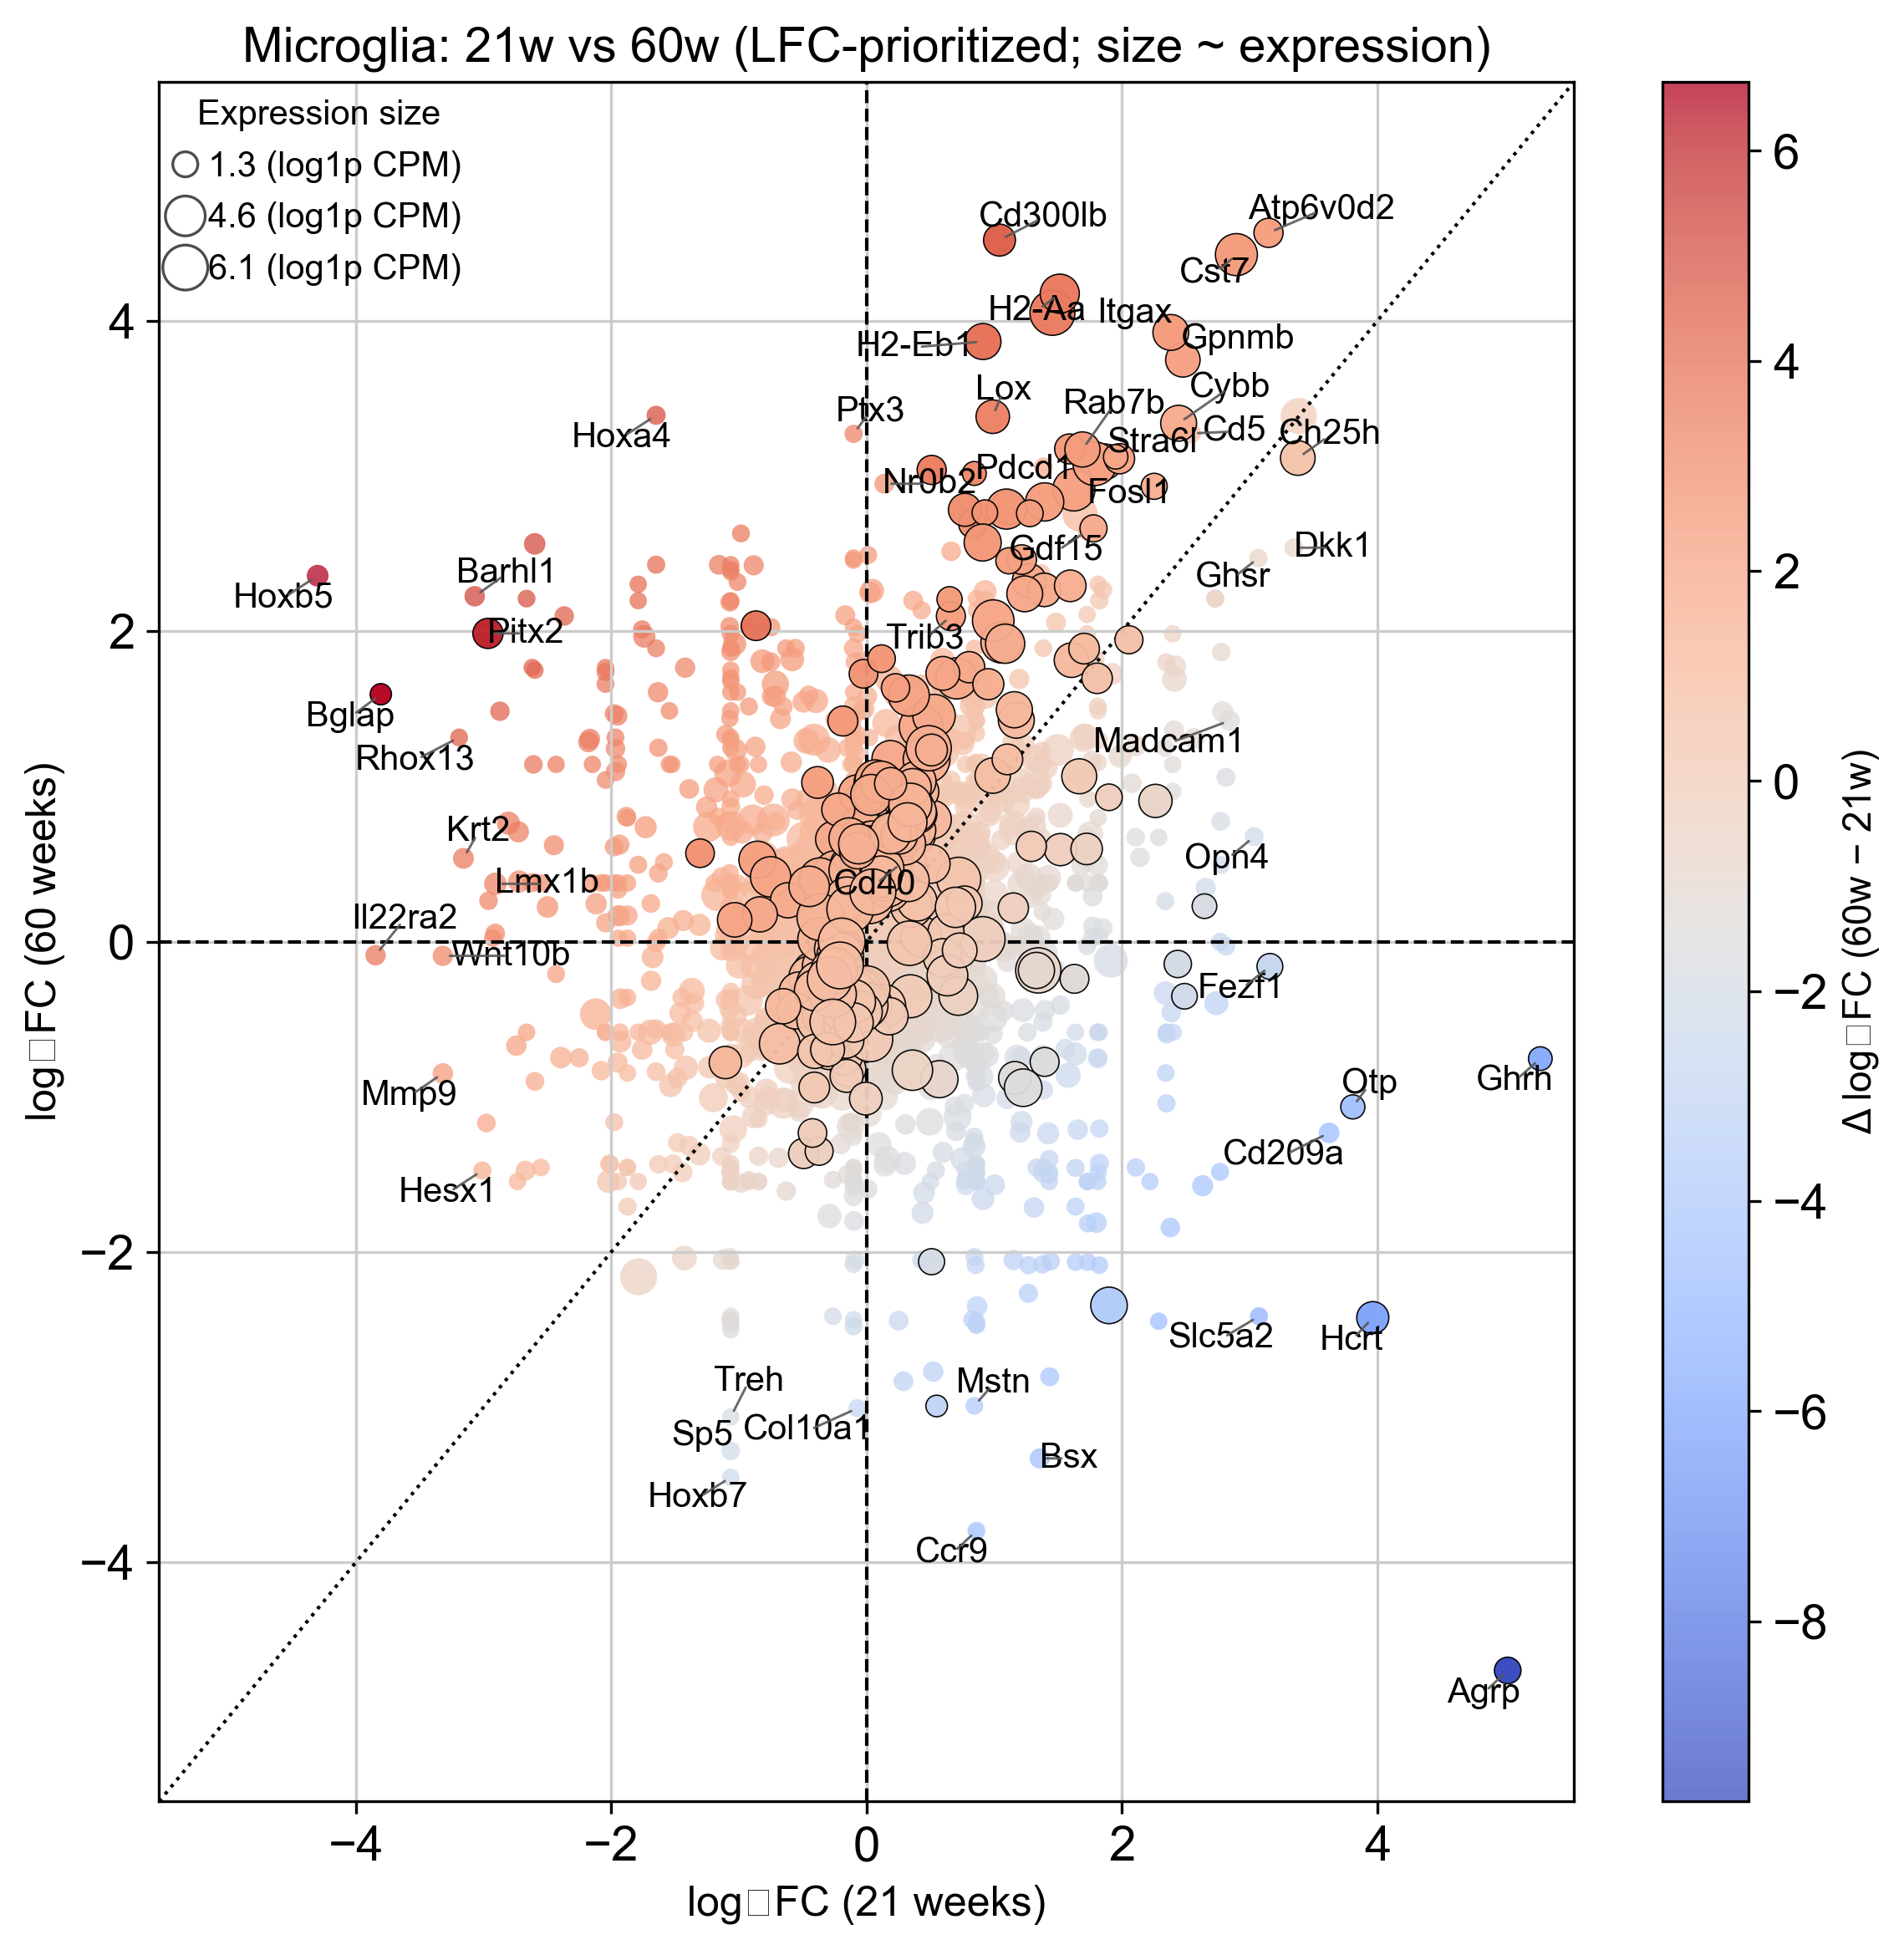

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Agrp,6.164,5.020,3.164,1.586,0.113,1.000,3.992,0.583,3.708,4.277,4.269,3.715
Atp6v0d2,5.047,3.147,1.306,2.411,0.016,1.000,7.235,0.833,0.796,13.674,3.478,10.993
Barhl1,1.641,-3.069,1.968,-1.559,0.119,1.000,0.902,0.583,1.103,0.700,1.112,0.692
Bglap,2.582,-3.804,1.768,-2.152,0.031,1.000,1.114,0.583,1.745,0.484,1.752,0.477
Cd209a,1.179,3.622,2.706,1.339,0.181,1.000,0.964,0.583,0.796,1.131,0.819,1.109
Ch25h,16.060,3.376,1.585,2.130,0.033,1.000,26.316,1.000,5.315,47.317,11.020,41.613
Cst7,135.383,2.896,1.086,2.666,0.008,1.000,185.679,1.000,23.343,348.015,92.955,278.404
Dkk1,0.968,3.345,2.633,1.271,0.204,1.000,0.512,0.417,0.000,1.025,0.670,0.355
Fezf1,6.563,3.158,1.078,2.930,0.003,0.846,3.408,0.917,1.637,5.179,4.537,2.279
Ghrh,3.683,5.275,2.225,2.371,0.018,1.000,2.066,0.667,0.988,3.143,2.546,1.585


,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Agrp,6.716,-4.696,1.287,-3.649,0.000,0.221,3.992,0.583,3.708,4.277,4.269,3.715
Atp6v0d2,20.166,4.567,1.706,2.676,0.007,0.530,7.235,0.833,0.796,13.674,3.478,10.993
Bsx,1.580,-3.330,2.177,-1.530,0.126,0.999,0.822,0.500,1.025,0.619,0.767,0.877
Ccr9,1.049,-3.796,2.803,-1.355,0.176,0.999,0.348,0.250,0.580,0.116,0.116,0.580
Cd300lb,39.474,4.520,1.487,3.039,0.002,0.307,13.758,0.917,2.847,24.670,5.999,21.517
Cd5,1.112,3.275,2.798,1.170,0.242,0.999,0.739,0.417,0.136,1.342,0.872,0.606
Cst7,510.649,4.426,1.254,3.530,0.000,0.239,185.679,1.000,23.343,348.015,92.955,278.404
Cybb,101.533,3.340,1.395,2.394,0.017,0.798,35.608,1.000,7.462,63.755,15.835,55.382
Gpnmb,61.976,3.749,1.210,3.099,0.002,0.306,25.140,1.000,4.837,45.442,16.475,33.805
H2-Aa,221.478,4.175,1.258,3.320,0.001,0.247,82.260,1.000,17.634,146.887,43.766,120.755


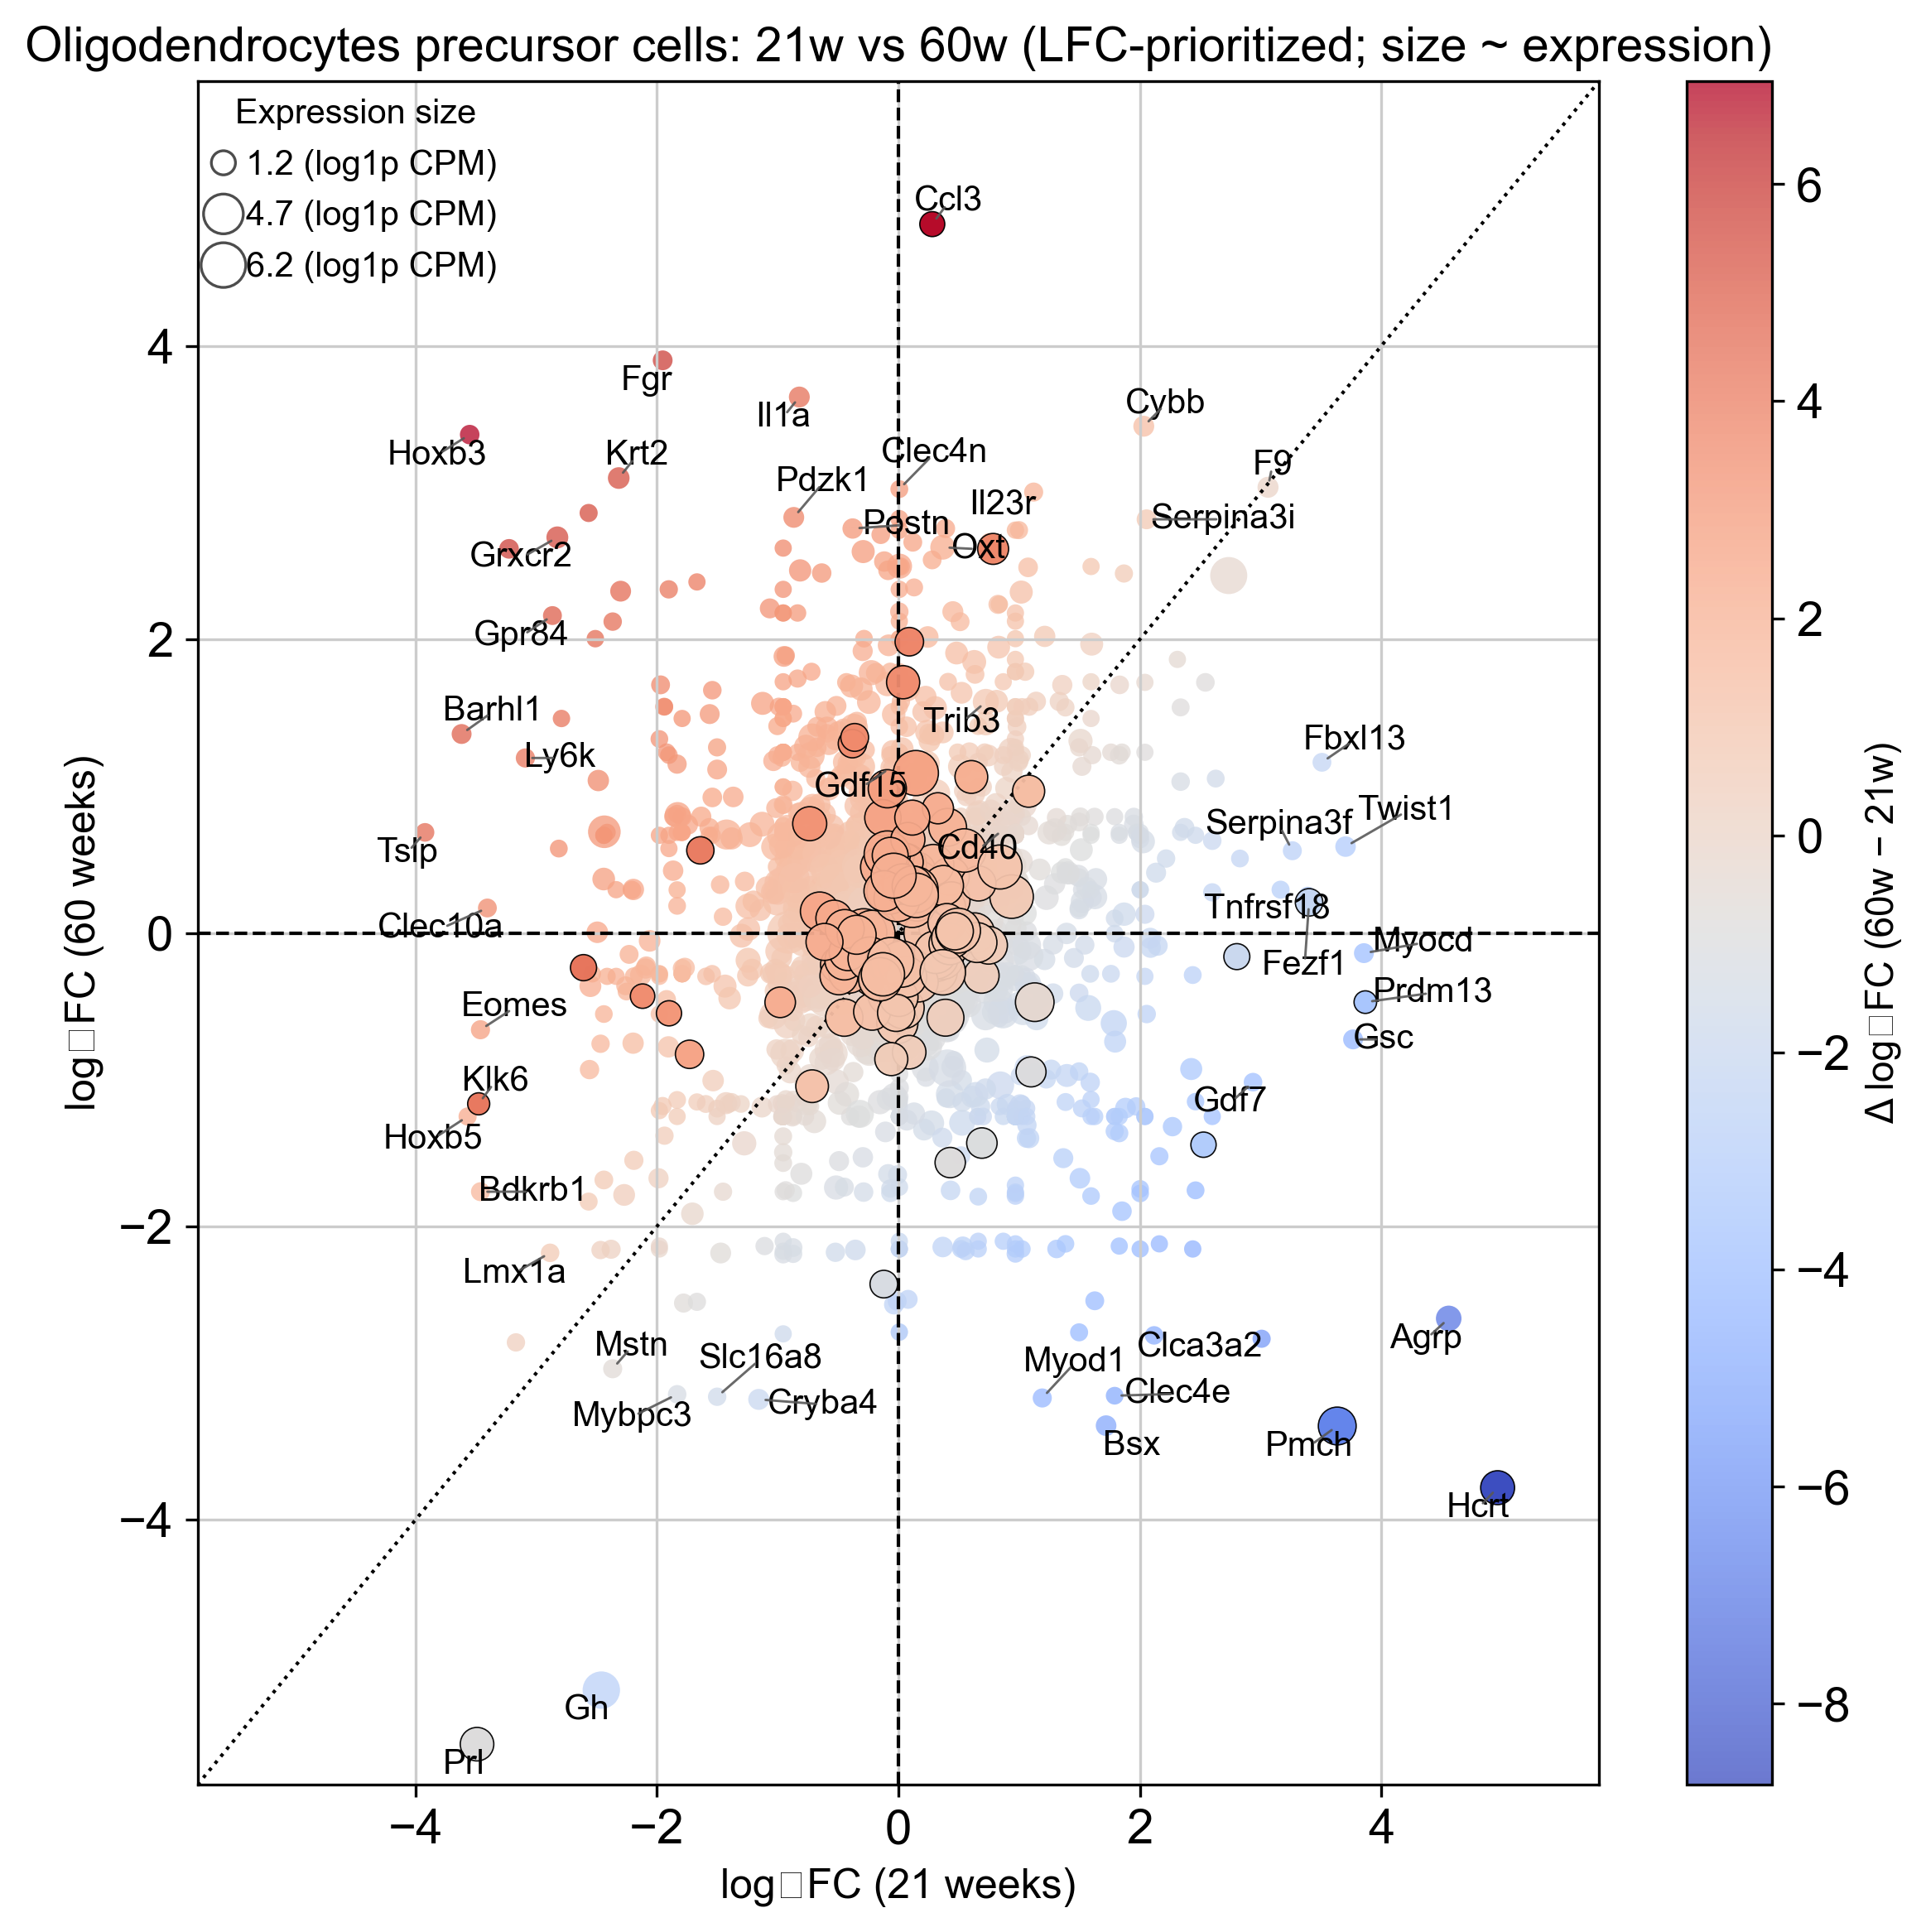

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Agrp,8.023,4.559,2.495,1.827,0.068,1.000,3.414,0.667,1.700,5.128,5.141,1.686
Barhl1,1.125,-3.618,2.610,-1.386,0.166,1.000,0.780,0.500,0.949,0.610,0.714,0.845
Bdkrb1,1.019,-3.462,2.592,-1.335,0.182,1.000,0.559,0.583,0.999,0.120,0.652,0.466
Clec10a,0.970,-3.404,2.588,-1.315,0.188,1.000,0.547,0.500,0.844,0.250,0.618,0.476
Eomes,1.019,-3.462,2.592,-1.335,0.182,1.000,0.601,0.500,1.009,0.194,0.652,0.550
Fbxl13,1.053,3.509,2.583,1.359,0.174,1.000,0.538,0.500,0.122,0.955,0.677,0.399
Fezf1,11.172,3.402,0.822,4.138,0.000,0.029,5.232,0.917,2.182,8.281,7.121,3.343
Gsc,1.268,3.767,2.483,1.517,0.129,1.000,0.772,0.667,0.458,1.085,0.808,0.735
Hcrt,26.136,4.964,0.844,5.884,0.000,0.000,24.060,1.000,29.827,18.292,16.643,31.476
Hoxb3,1.096,-3.551,2.672,-1.329,0.184,1.000,0.695,0.333,0.697,0.694,0.697,0.694


,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Bsx,1.833,-3.358,1.864,-1.801,0.072,1.0,0.977,0.583,1.223,0.731,0.806,1.148
Ccl3,5.882,4.831,1.616,2.990,0.003,1.0,2.950,0.833,1.113,4.786,2.196,3.704
Cryba4,1.660,-3.179,1.900,-1.673,0.094,1.0,1.078,0.750,1.679,0.478,1.113,1.044
Cybb,2.411,3.454,1.807,1.911,0.056,1.0,1.057,0.583,0.239,1.876,0.597,1.518
F9,1.812,3.038,1.842,1.649,0.099,1.0,1.095,0.583,0.224,1.965,1.059,1.130
Fgr,1.496,3.903,2.382,1.638,0.101,1.0,0.753,0.500,0.451,1.056,0.573,0.934
Gh,5.859,-5.161,2.682,-1.924,0.054,1.0,59.116,0.750,100.512,17.719,114.537,3.694
Grxcr2,1.508,2.696,1.935,1.393,0.164,1.0,1.383,0.750,1.703,1.063,1.821,0.944
Hcrt,49.937,-3.781,1.289,-2.933,0.003,1.0,24.060,1.000,29.827,18.292,16.643,31.476
Hoxb3,1.104,3.396,2.639,1.287,0.198,1.0,0.695,0.333,0.697,0.694,0.697,0.694


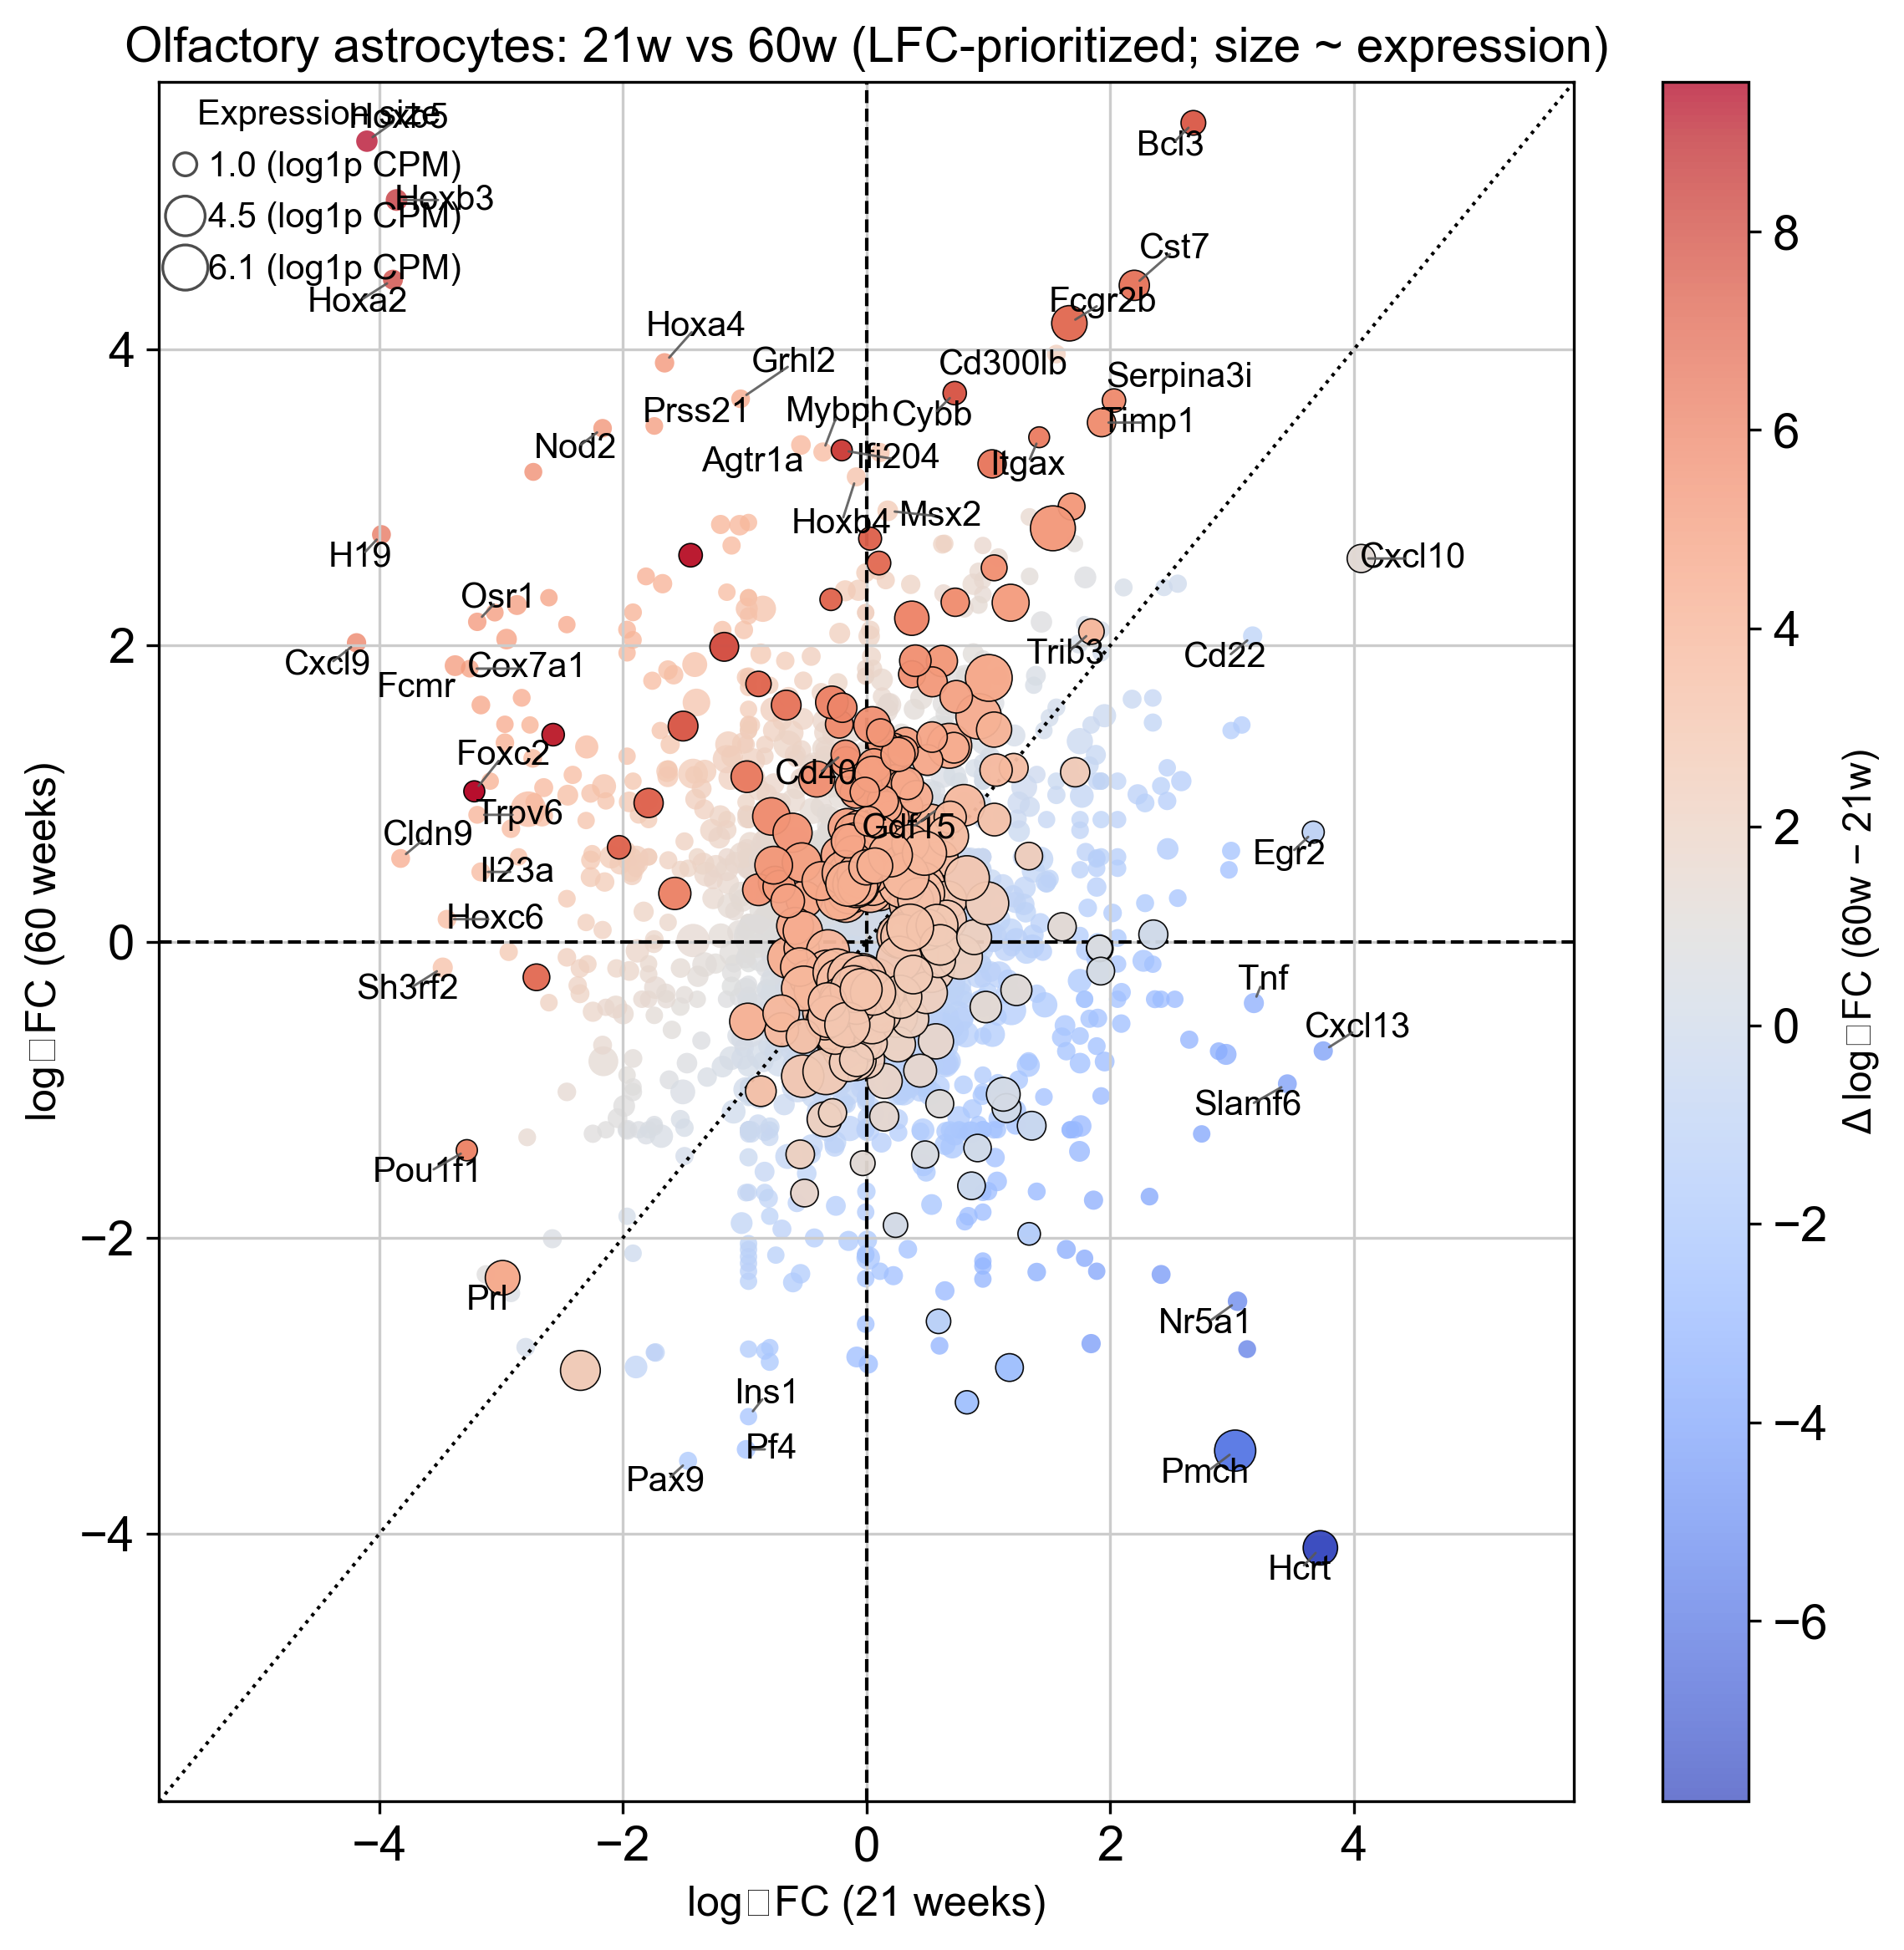

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Cldn9,1.290,-3.825,2.585,-1.480,0.139,1.0,0.431,0.583,0.688,0.173,0.571,0.290
Cxcl10,17.037,4.060,2.340,1.735,0.083,1.0,5.405,0.750,0.896,9.914,7.455,3.355
Cxcl13,1.223,3.748,2.748,1.364,0.173,1.0,0.510,0.667,0.303,0.717,0.534,0.487
Cxcl9,1.668,-4.187,2.675,-1.565,0.118,1.0,0.528,0.417,0.797,0.259,0.739,0.317
Egr2,2.423,3.666,1.845,1.987,0.047,1.0,1.190,0.833,0.560,1.820,1.062,1.317
Fcmr,2.101,-3.378,1.941,-1.740,0.082,1.0,0.870,0.750,1.007,0.734,0.913,0.828
Foxc2,3.375,-3.220,1.559,-2.065,0.039,1.0,0.907,0.750,1.445,0.368,1.461,0.353
H19,1.478,-3.982,2.507,-1.588,0.112,1.0,0.434,0.500,0.640,0.229,0.640,0.229
Hcrt,48.283,3.725,1.296,2.873,0.004,1.0,23.187,1.000,25.311,21.063,21.050,25.324
Hoxa2,1.385,-3.888,2.826,-1.376,0.169,1.0,0.668,0.333,0.598,0.738,0.598,0.738


,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Bcl3,9.581,5.530,1.624,3.406,0.001,0.113,2.397,0.750,0.308,4.487,1.721,3.074
Cd300lb,1.648,3.968,2.764,1.436,0.151,NaN,0.416,0.417,0.070,0.763,0.305,0.527
Cst7,45.997,4.433,1.344,3.297,0.001,0.120,8.600,0.833,1.107,16.092,2.393,14.807
Cybb,7.901,3.705,1.256,2.950,0.003,0.232,1.723,0.750,0.512,2.934,0.906,2.539
Fcgr2b,134.087,4.176,1.151,3.628,0.000,0.078,29.520,1.000,6.085,52.955,15.835,43.205
Grhl2,1.273,3.666,2.560,1.432,0.152,NaN,0.412,0.667,0.283,0.542,0.416,0.409
Hcrt,77.980,-4.094,0.554,-7.389,0.000,0.000,23.187,1.000,25.311,21.063,21.050,25.324
Hoxa2,2.329,4.471,2.744,1.629,0.103,NaN,0.668,0.333,0.598,0.738,0.598,0.738
Hoxa4,1.575,3.909,3.214,1.216,0.224,NaN,0.539,0.333,0.447,0.632,0.580,0.498
Hoxb3,3.308,5.009,4.213,1.189,0.234,NaN,1.138,0.417,1.142,1.134,1.228,1.048


In [328]:
from IPython.display import display, HTML
import pandas as pd

def _display_top_table(res, top, cell, age, head=20):
    if res is None or not isinstance(res, pd.DataFrame) or len(top) == 0:
        display(HTML(f"<h4 style='color:gray;margin:0.6em 0;'>⚠️ {cell} — {age}: no data</h4>"))
        return
    idx = res.index.intersection(pd.Index(top))
    if len(idx) == 0:
        display(HTML(f"<h4 style='color:gray;margin:0.6em 0;'>⚠️ {cell} — {age}: none of the requested genes found</h4>"))
        return
    sub = res.loc[idx].copy()
    # round numeric columns for readability
    num_cols = sub.select_dtypes(include="number").columns
    sub[num_cols] = sub[num_cols].round(3)
    # nice title
    display(HTML(
        f"<h3 style='color:#2a4d69;margin:0.6em 0 0.2em 0;'>{cell} — Top {len(idx)} genes at {age}</h3>"
    ))
    display(sub.head(head))

# Iterate all cell classes in results and make age-comparison scatters
forced = ['Trib3','Cd40','Gdf15']

for cell, pack in results.items():
    se = pack.get("simple_effects", {})
    if "21" not in se or "60" not in se or se["21"] is None or se["60"] is None:
        print(f"Skipping {cell}: missing 21/60 results.")
        continue

    res21 = se["21"]
    res60 = se["60"]

    # Expression to control point size (if available)
    gstats = pack.get("gene_stats", None)
    expr_series = gstats["mean_cpm_all"] if (gstats is not None and "mean_cpm_all" in gstats.columns) else None

    # Pick top genes per age (LFC-prioritized)
    picks, top21, top60 = pick_top_per_age(
        res21, res60,
        lfc_col='log2FC_mtDSB_vs_control',
        padj_col='pvalue_mtDSB_vs_control',  # p-value used; beta_p=0 => pure LFC ranking
        q=0.25,
        top_n_each=20,
        alpha_lfc=1.0,
        beta_p=0.0,
        force_lfc_min=0.0,
        max_labels=100
    )

    # Ensure uniqueness and include forced genes
    labels = list(dict.fromkeys(list(picks) + forced))

    # Plot with ΔLFC color and size ~ mean CPM
    _ = compare_lfc_scatter_colored_labels(
        res_early=res21,
        res_late=res60,
        lfc_col='log2FC_mtDSB_vs_control',
        padj_col='pvalue_mtDSB_vs_control',
        highlight_genes=labels,
        title=f"{cell}: 21w vs 60w (LFC-prioritized; size ~ expression)",
        top_n_delta=0,
        expr=expr_series,
        size_min=25,
        size_max=180,
        use_log_expr=True
    )

    # Pretty, titled tables for each age
    _display_top_table(res21, top21, cell, "21w")
    _display_top_table(res60, top60, cell, "60w")

## Save results

In [318]:
import os

def save_all_results(results, outdir="../../results"):
    """
    Save all DE results from the nested `results` dict into organized subfolders.
    Structure:
        outdir/
          └── <cell_type>/
                ├── simple_effect_age_<age>.csv
                ├── deltaLFC_<ageA>_vs_<ageB>.csv
    """
    os.makedirs(outdir, exist_ok=True)

    for ct, rdict in results.items():
        ct_dir = os.path.join(outdir, ct.replace(" ", "_"))
        os.makedirs(ct_dir, exist_ok=True)

        # --- Simple effects (mtDSB vs control per age) ---
        for age, df in rdict.get("simple_effects", {}).items():
            if df is not None:
                fname = f"simple_effect_age_{age}.csv"
                df.to_csv(os.path.join(ct_dir, fname))

        # --- Delta-LFC (interaction proxy between ages) ---
        for (a1, a2), df in rdict.get("deltas", {}).items():
            if df is not None:
                fname = f"deltaLFC_{a1}_vs_{a2}.csv"
                df.to_csv(os.path.join(ct_dir, fname))

        print(f"✅ Saved {ct} results to {ct_dir}")

In [319]:
save_all_results(results, outdir="../results/age")

✅ Saved Mature oligodendrocytes results to ../results/age/Mature_oligodendrocytes
✅ Saved Telencephalon astrocytes results to ../results/age/Telencephalon_astrocytes
✅ Saved Microglia results to ../results/age/Microglia
✅ Saved Oligodendrocytes precursor cells results to ../results/age/Oligodendrocytes_precursor_cells
✅ Saved Olfactory astrocytes results to ../results/age/Olfactory_astrocytes
